In [1]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import sweetviz as sv
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import warnings
from scipy.stats import zscore, mode
from sklearn.metrics import (silhouette_samples,silhouette_score,make_scorer,mean_absolute_error, r2_score, mean_squared_error,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)
from sklearn.base import (BaseEstimator,TransformerMixin,ClassifierMixin,RegressorMixin)
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, BaseCrossValidator, KFold, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import joblib
from joblib import load
import os
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.clustering import TimeSeriesKMeans, silhouette_score as ts_silhouette_score
import shap
from lime import lime_tabular
from sklearn.model_selection import GroupKFold

In [2]:
# Cargar los datos desde el archivo Excel
file_path = 'C:/Users/Andy/OneDrive/Desktop/MCD/Tesis/Datos_fuente_Bloomberg/en valores/serie completa 2014-2024/Dataset/dataset_completo.xlsx'
df = pd.read_excel(file_path, sheet_name='dataset')

In [3]:
df.head()

,Empresa,Fecha,P_E,P_B,P_TB,P_S,P_CF,P_FCF,P_Share,ROCE_sp,...,Efectivo y equiv_l,CPI,CPI_Exp_mediana,CPI_Exp_promedio,Fed Funds Rate,Fed Funds Rate_Exp_mediana,Fed Funds Rate_Exp_promedio,Non farm payrolls,Non farm payrolls_Exp_mediana,Non farm payrolls_Exp_promedio
0,FLWS US Equity,20140930,31.7207,2.5643,6.1415,0.6062,10.3190,21.6093,7.19,5.886400,...,1.314000,1.7,0.019,0.0191,0.25,0.0025,0.0025,307,230k,226.13k
1,FLWS US Equity,20141031,35.4266,2.8638,6.859,0.677,11.5246,24.1339,8.03,8.881198,...,2.610333,1.7,0.016,0.0162,0.25,0.0025,0.0025,240,215k,216.22k
2,FLWS US Equity,20141128,37.7207,3.0493,7.3032,0.7208,12.2709,25.6967,8.55,9.469145,...,3.906667,1.3,0.016,0.0157,0.25,0.0025,0.0025,284,235k,236.62k
3,FLWS US Equity,20141231,11.3711,2.3843,8.1913,0.5153,2.6214,3.0449,8.24,8.721900,...,5.203000,0.8,0.014,0.0142,0.25,0.0025,0.0025,278,230k,229.16k
4,FLWS US Equity,20150130,10.8881,2.283,7.8433,0.4934,2.5100,2.9155,7.89,7.711122,...,4.188000,-0.1,0.007,0.0069,0.25,0.0025,0.0025,196,240k,234.73k


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166440 entries, 0 to 166439
Data columns (total 42 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Empresa                         166440 non-null  object 
 1   Fecha                           166440 non-null  int64  
 2   P_E                             87792 non-null   float64
 3   P_B                             119348 non-null  object 
 4   P_TB                            92514 non-null   object 
 5   P_S                             117703 non-null  object 
 6   P_CF                            95713 non-null   float64
 7   P_FCF                           69291 non-null   object 
 8   P_Share                         131345 non-null  object 
 9   ROCE_sp                         115613 non-null  float64
 10  ROCE_l                          115613 non-null  float64
 11  EBIT_sp                         115176 non-null  float64
 12  EBIT_l          

In [5]:
# Quitar "k" de las columnas "Non farm payrolls_Exp_mediana" y "Non farm payrolls_Exp_promedio"
df['Non farm payrolls_Exp_mediana'] = df['Non farm payrolls_Exp_mediana'].astype(str).str.replace('k', '')
df['Non farm payrolls_Exp_promedio'] = df['Non farm payrolls_Exp_promedio'].astype(str).str.replace('k', '')

# Convertir las columnas a valores numéricos
df['Non farm payrolls_Exp_mediana'] = pd.to_numeric(df['Non farm payrolls_Exp_mediana'], errors='coerce')
df['Non farm payrolls_Exp_promedio'] = pd.to_numeric(df['Non farm payrolls_Exp_promedio'], errors='coerce')
df['P_B'] = pd.to_numeric(df['P_B'], errors='coerce')
df['P_TB'] = pd.to_numeric(df['P_TB'], errors='coerce')
df['P_S'] = pd.to_numeric(df['P_S'], errors='coerce')
df['P_FCF'] = pd.to_numeric(df['P_FCF'], errors='coerce')
df['P_Share'] = pd.to_numeric(df['P_Share'], errors='coerce')

In [6]:
# Convertir la columna de fecha a formato datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y%m%d')

# Extraer características temporales relevantes
df['mes'] = df['Fecha'].dt.month
df['año'] = df['Fecha'].dt.year
df['periodo'] = df['Fecha'].dt.to_period('M')

In [7]:
# Convertir CPI y Fed Funds Rate a decimales
df['CPI'] = df['CPI'] / 100
df['Fed Funds Rate'] = df['Fed Funds Rate'] / 100

In [8]:
# Calcular diferencias en puntos básicos
df['dif_CPI_mediana'] = (df['CPI'] - df['CPI_Exp_mediana']) * 10000
df['dif_CPI_promedio'] = (df['CPI'] - df['CPI_Exp_promedio']) * 10000

df['dif_FFR_mediana'] = (df['Fed Funds Rate'] - df['Fed Funds Rate_Exp_mediana']) * 10000
df['dif_FFR_promedio'] = (df['Fed Funds Rate'] - df['Fed Funds Rate_Exp_promedio']) * 10000

# Calcular diferencia
df['dif_NFP_mediana'] = (df['Non farm payrolls'] - df['Non farm payrolls_Exp_mediana'])
df['dif_NFP_promedio'] = (df['Non farm payrolls'] - df['Non farm payrolls_Exp_promedio'])

In [9]:
# Lista de columnas numéricas para análisis con mensualización lineal de los ratios 
# y variables macroeconómicas calculadas con mediana
columnas_numericas_lineal_mediana= [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_l',
    'EBIT_l',
    'Total Activos_l',
    'Deuda a LP_l',
    'ROA_l',
    'Beneficio neto_l',
    'ROI_l',
    'EV_l',
    'Cap de mercado_l',
    'Deuda a CP_l',
    'Efectivo y equiv_l',
    'dif_CPI_mediana',
    'dif_FFR_mediana',
    'dif_NFP_mediana'
]

In [10]:
# Lista de columnas numéricas para análisis con mensualización spline de los ratios 
# y variables macroeconómicas calculadas con mediana
columnas_numericas_spline_mediana = [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_sp',
    'EBIT_sp',
    'Total Activos_sp',
    'Deuda a LP_sp',
    'ROA_sp',
    'Beneficio neto_sp',
    'ROI_sp',
    'EV_sp',
    'Cap de mercado_sp',
    'Deuda a CP_sp',
    'Efectivo y equiv_sp',
    'dif_CPI_mediana',
    'dif_FFR_mediana',
    'dif_NFP_mediana'
]

In [11]:
# Lista de columnas numéricas para análisis con mensualización lineal de los ratios 
# y variables macroeconómicas calculadas con promedio
columnas_numericas_lineal_promedio = [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_l',
    'EBIT_l',
    'Total Activos_l',
    'Deuda a LP_l',
    'ROA_l',
    'Beneficio neto_l',
    'ROI_l',
    'EV_l',
    'Cap de mercado_l',
    'Deuda a CP_l',
    'Efectivo y equiv_l',
    'dif_CPI_promedio',
    'dif_FFR_promedio',
    'dif_NFP_promedio'
]

In [12]:
# Lista de columnas numéricas para análisis con mensualización spline de los ratios 
# y variables macroeconómicas calculadas con promedio
columnas_numericas_spline_promedio = [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_sp',
    'EBIT_sp',
    'Total Activos_sp',
    'Deuda a LP_sp',
    'ROA_sp',
    'Beneficio neto_sp',
    'ROI_sp',
    'EV_sp',
    'Cap de mercado_sp',
    'Deuda a CP_sp',
    'Efectivo y equiv_sp',
    'dif_CPI_promedio',
    'dif_FFR_promedio',
    'dif_NFP_promedio'
]

In [13]:
listas_columnas = {
    'lineal_mediana': columnas_numericas_lineal_mediana,
    'spline_mediana': columnas_numericas_spline_mediana,
    'lineal_promedio': columnas_numericas_lineal_promedio,
    'spline_promedio': columnas_numericas_spline_promedio
}

In [14]:
listas_columnas

{'lineal_mediana': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_l',
  'EBIT_l',
  'Total Activos_l',
  'Deuda a LP_l',
  'ROA_l',
  'Beneficio neto_l',
  'ROI_l',
  'EV_l',
  'Cap de mercado_l',
  'Deuda a CP_l',
  'Efectivo y equiv_l',
  'dif_CPI_mediana',
  'dif_FFR_mediana',
  'dif_NFP_mediana'],
 'spline_mediana': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_sp',
  'EBIT_sp',
  'Total Activos_sp',
  'Deuda a LP_sp',
  'ROA_sp',
  'Beneficio neto_sp',
  'ROI_sp',
  'EV_sp',
  'Cap de mercado_sp',
  'Deuda a CP_sp',
  'Efectivo y equiv_sp',
  'dif_CPI_mediana',
  'dif_FFR_mediana',
  'dif_NFP_mediana'],
 'lineal_promedio': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_l',
  'EBIT_l',
  'Total Activos_l',
  'Deuda a LP_l',
  'ROA_l',
  'Beneficio neto_l',
  'ROI_l',
  'EV_l',
  'Cap de mercado_l',
  'Deuda a CP_l',
  'Efectivo y equiv_l',
  'dif_CPI_promedio',
  'dif_FFR_promedio',
  'dif_NFP_promedio'],
 'spline_promedio': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_sp',
  'E

In [15]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 1: Importaciones y Funciones Auxiliares                  │
# └─────────────────────────────────────────────────────────────────┘
import pandas as pd
import numpy as np

def pct_missing_by_column(df, columns):
    """Devuelve % de NaNs por columna, ordenado descendente."""
    return (df[columns].isna().mean() * 100).sort_values(ascending=False)

def pct_missing_by_group(df, group_col, features):
    """Devuelve Series con el máximo % de NaNs en cualquier feature por grupo."""
    missing = df.groupby(group_col)[features]\
                .apply(lambda g: g.isna().mean()*100)
    return missing.max(axis=1)

def filter_companies_by_target_missing(df, group_col, target_col):
    """Filtra y devuelve df sin empresas que tengan ANY NaN en target_col."""
    ok = ~df.groupby(group_col)[target_col].apply(lambda s: s.isna().any())
    valid_companies = ok[ok].index
    return df[df[group_col].isin(valid_companies)].copy()

def impute_by_group(df, group_col, features, methods=('ffill',), fill_value=0): # <-- Cambiar default
    """Imputa NaNs por grupo usando .ffill() y termina con fillna(fill_value)."""
    df2 = df.sort_values([group_col, 'Fecha']).copy()
    for m in methods:
        df2[features] = df2.groupby(group_col)[features]\
                            .transform(lambda g: getattr(g, m)())
    return df2.fillna(fill_value)

def create_lags(df, group_col, date_col, features, lag=1):
    """Genera columnas de lag para cada feature dentro de cada grupo."""
    df2 = df.sort_values([group_col, date_col]).copy()
    for feat in features:
        df2[f"{feat}_lag{lag}"] = df2.groupby(group_col)[feat].shift(lag)
    return df2


In [16]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 3: Conversión Masiva a Numérico                         │
# └─────────────────────────────────────────────────────────────────┘
# Crear set de features base (sin 'Empresa' ni 'Fecha'), añadir 'P_E' si existe
features_base = {
    col for cols in listas_columnas.values()
            for col in cols if col not in ('Empresa','Fecha')
}
if 'P_E' in df.columns:
    features_base.add('P_E')
numeric_cols = [c for c in sorted(features_base) if c in df.columns]

# Vectorizado
nan_before = df[numeric_cols].isna().sum()
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
nan_after = df[numeric_cols].isna().sum()
print("NaNs añadidos:", (nan_after - nan_before).sum())

NaNs añadidos: 0


In [17]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 4: Filtrar Empresas con NaNs en el Target P_E           │
# └─────────────────────────────────────────────────────────────────┘
df_no_PE_NaN = filter_companies_by_target_missing(df, 'Empresa', 'P_E')
print("Empresas tras filtrar P_E NaN:", df_no_PE_NaN['Empresa'].nunique())

Empresas tras filtrar P_E NaN: 403


In [18]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 5: Excluir Columnas Críticas con Demasiados NaNs        │
# └─────────────────────────────────────────────────────────────────┘
col_pct = pct_missing_by_column(df_no_PE_NaN, numeric_cols)
col_pct

EBIT_sp                29.698098
EBIT_l                 29.698098
EV_sp                  28.662117
EV_l                   28.662117
Deuda a CP_l            6.952026
Deuda a CP_sp           6.952026
ROCE_sp                 3.196857
ROCE_l                  3.196857
ROI_sp                  2.045079
ROI_l                   2.045079
Deuda a LP_sp           1.774194
Deuda a LP_l            1.774194
ROA_l                   1.600496
ROA_sp                  1.600496
P_B                     1.565343
Total Activos_sp        1.428867
Total Activos_l         1.428867
Efectivo y equiv_l      1.418528
Efectivo y equiv_sp     1.418528
Beneficio neto_sp       1.296526
Beneficio neto_l        1.296526
Cap de mercado_sp       1.265509
Cap de mercado_l        1.265509
P_S                     0.051696
P_Share                 0.002068
P_E                     0.000000
dif_CPI_mediana         0.000000
dif_CPI_promedio        0.000000
dif_FFR_mediana         0.000000
dif_FFR_promedio        0.000000
dif_NFP_me

In [19]:
umbral_col = 5.0   # % máximo de NaNs tolerable
cols_to_exclude = col_pct[col_pct > umbral_col].index.tolist()
features_kept = [c for c in numeric_cols if c not in cols_to_exclude]
print(f"Columnas excluidas (> {umbral_col}% NaNs):", cols_to_exclude)

Columnas excluidas (> 5.0% NaNs): ['EBIT_sp', 'EBIT_l', 'EV_sp', 'EV_l', 'Deuda a CP_l', 'Deuda a CP_sp']


In [20]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 6: Excluir Empresas con Demasiados NaNs en Features     │
# └─────────────────────────────────────────────────────────────────┘
umbral_grp = 10   # % máximo de NaNs por empresa
grp_pct = pct_missing_by_group(df_no_PE_NaN, 'Empresa', features_kept)
empresas_final = grp_pct[grp_pct <= umbral_grp].index.tolist()
df_final = df_no_PE_NaN[df_no_PE_NaN['Empresa'].isin(empresas_final)].copy()
print("Empresas finales (<= {umbral_grp}% NaNs):", len(empresas_final))


Empresas finales (<= {umbral_grp}% NaNs): 381


In [21]:
# --------------------------------------------------------------------
# BLOQUE 6 bis –  Split por empresa ANTES de imputar y crear lags
# --------------------------------------------------------------------
from sklearn.model_selection import train_test_split

empresas_train, empresas_test = train_test_split(
        df_no_PE_NaN['Empresa'].unique(),
        test_size=0.20,                # ⇦  ajusta si quieres otro ratio
        random_state=42,
        shuffle=True)

df_train_raw = df_no_PE_NaN[df_no_PE_NaN['Empresa'].isin(empresas_train)].copy()
df_test_raw  = df_no_PE_NaN[df_no_PE_NaN['Empresa'].isin(empresas_test)].copy()

print(f"Empresas en TRAIN: {len(empresas_train)}   •   Empresas en TEST: {len(empresas_test)}")


Empresas en TRAIN: 322   •   Empresas en TEST: 81


In [22]:
# --------------------------------------------------------------------
# BLOQUE 7 –  Imputación *dentro* de cada subconjunto
# --------------------------------------------------------------------
df_train = impute_by_group(df_train_raw, 'Empresa', features_kept)
df_test  = impute_by_group(df_test_raw,  'Empresa', features_kept)

print("NaNs en TRAIN después de imputar:", df_train[features_kept].isna().sum().sum())
print("NaNs en TEST  después de imputar:", df_test[features_kept].isna().sum().sum())


NaNs en TRAIN después de imputar: 0
NaNs en TEST  después de imputar: 0


In [24]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 8 – Crear DataFrames con lags **separados** para TRAIN y TEST │
# └─────────────────────────────────────────────────────────────────┘

# Número de meses de rezago que quieres generar
LAG_VALUE_EXPERIMENT = 1        # ← o 3, 6, etc.

dfs_shifted_train = {}
dfs_shifted_test  = {}

# Asegurarnos de que P_E entre en el lag
features_kept_for_lags = features_kept.copy()
if 'P_E' not in features_kept_for_lags:
    features_kept_for_lags.append('P_E')

for metodo, cols_originales_metodo in listas_columnas.items():
    print(f"\n=== Método: {metodo}  |  Generando lag{LAG_VALUE_EXPERIMENT} ===")

    # 1️⃣  Features base válidas (existen + pasaron filtros)
    features_base = [
        c for c in cols_originales_metodo
        if c in features_kept_for_lags and c in df_train.columns
           and c not in ('Empresa', 'Fecha')
    ]
    if 'P_E' in df_train.columns and 'P_E' not in features_base:
        features_base.append('P_E')

    if not features_base:
        print("  • Sin features válidas, se omite.")
        continue

    cols_necesarias = ['Empresa', 'Fecha'] + features_base

    # 2️⃣  Sub-dataframes por conjunto
    df_tr_base = df_train[cols_necesarias].copy()
    df_te_base = df_test[cols_necesarias].copy()

    # 3️⃣  Generar lags dentro de cada subconjunto (sin mezclar info)
    df_tr_lag = create_lags(df_tr_base, 'Empresa', 'Fecha',
                            features_base, lag=LAG_VALUE_EXPERIMENT)
    df_te_lag = create_lags(df_te_base, 'Empresa', 'Fecha',
                            features_base, lag=LAG_VALUE_EXPERIMENT)

    # 4️⃣  Columnas de lag que se usarán como predictores
    pred_cols = [f"{c}_lag{LAG_VALUE_EXPERIMENT}" for c in features_base]

    # 5️⃣  Drop NaN en los lags
    dropped_tr = df_tr_lag.shape[0]
    dropped_te = df_te_lag.shape[0]
    df_tr_lag.dropna(subset=pred_cols, inplace=True)
    df_te_lag.dropna(subset=pred_cols, inplace=True)
    print(f"  • Filas eliminadas TRAIN: {dropped_tr - len(df_tr_lag)}")
    print(f"  • Filas eliminadas TEST : {dropped_te - len(df_te_lag)}")

    # 6️⃣  Conservar solo columnas finales
    cols_final = ['Empresa', 'Fecha', 'P_E'] + pred_cols
    cols_final = [c for c in cols_final if c in df_tr_lag.columns]

    dfs_shifted_train[metodo] = df_tr_lag[cols_final].copy()
    dfs_shifted_test[metodo]  = df_te_lag[cols_final].copy()

    print(f"  →  TRAIN {dfs_shifted_train[metodo].shape}  |  TEST {dfs_shifted_test[metodo].shape}")
    if f'P_E_lag{LAG_VALUE_EXPERIMENT}' in pred_cols:
        print("     ✔  'P_E_lag1' incluido como predictor.")



=== Método: lineal_mediana  |  Generando lag1 ===
  • Filas eliminadas TRAIN: 322
  • Filas eliminadas TEST : 81
  →  TRAIN (38318, 18)  |  TEST (9639, 18)
     ✔  'P_E_lag1' incluido como predictor.

=== Método: spline_mediana  |  Generando lag1 ===
  • Filas eliminadas TRAIN: 322
  • Filas eliminadas TEST : 81
  →  TRAIN (38318, 18)  |  TEST (9639, 18)
     ✔  'P_E_lag1' incluido como predictor.

=== Método: lineal_promedio  |  Generando lag1 ===
  • Filas eliminadas TRAIN: 322
  • Filas eliminadas TEST : 81
  →  TRAIN (38318, 18)  |  TEST (9639, 18)
     ✔  'P_E_lag1' incluido como predictor.

=== Método: spline_promedio  |  Generando lag1 ===
  • Filas eliminadas TRAIN: 322
  • Filas eliminadas TEST : 81
  →  TRAIN (38318, 18)  |  TEST (9639, 18)
     ✔  'P_E_lag1' incluido como predictor.


## Dlocal

In [25]:
# Cargar los datos desde el archivo Excel
file_path = 'C:/Users/Andy/OneDrive/Desktop/MCD/Tesis/Datos_fuente_Bloomberg/en valores/serie completa 2014-2024/Dataset/dataset_dlocal_casi sin vacías.xlsx'
df_dlocal = pd.read_excel(file_path, sheet_name='dataset')

In [26]:
df_dlocal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Empresa                         28 non-null     object 
 1   Fecha                           28 non-null     int64  
 2   P_E                             28 non-null     float64
 3   P_B                             28 non-null     float64
 4   P_S                             28 non-null     float64
 5   P_Share                         28 non-null     float64
 6   ROCE_sp                         28 non-null     float64
 7   ROCE_l                          28 non-null     float64
 8   EBIT_sp                         28 non-null     float64
 9   EBIT_l                          28 non-null     float64
 10  Total Activos_sp                28 non-null     float64
 11  Total Activos_l                 28 non-null     float64
 12  Deuda a LP_sp                   28 non

In [27]:
# Quitar "k" de las columnas "Non farm payrolls_Exp_mediana" y "Non farm payrolls_Exp_promedio"
df_dlocal['Non farm payrolls_Exp_mediana'] = df_dlocal['Non farm payrolls_Exp_mediana'].astype(str).str.replace('k', '')
df_dlocal['Non farm payrolls_Exp_promedio'] = df_dlocal['Non farm payrolls_Exp_promedio'].astype(str).str.replace('k', '')

# Convertir las columnas a valores numéricos
df_dlocal['Non farm payrolls_Exp_mediana'] = pd.to_numeric(df_dlocal['Non farm payrolls_Exp_mediana'], errors='coerce')
df_dlocal['Non farm payrolls_Exp_promedio'] = pd.to_numeric(df_dlocal['Non farm payrolls_Exp_promedio'], errors='coerce')

df_dlocal['P_B'] = pd.to_numeric(df_dlocal['P_B'], errors='coerce')
#df_dlocal['P_TB'] = pd.to_numeric(df_dlocal['P_TB'], errors='coerce')
df_dlocal['P_S'] = pd.to_numeric(df_dlocal['P_S'], errors='coerce')
#df_dlocal['P_FCF'] = pd.to_numeric(df_dlocal['P_FCF'], errors='coerce')
df_dlocal['P_Share'] = pd.to_numeric(df_dlocal['P_Share'], errors='coerce')

In [28]:
# Convertir la columna de fecha a formato datetime
df_dlocal['Fecha'] = pd.to_datetime(df_dlocal['Fecha'], format='%Y%m%d')

# Extraer características temporales relevantes
df_dlocal['mes'] = df_dlocal['Fecha'].dt.month
df_dlocal['año'] = df_dlocal['Fecha'].dt.year
df_dlocal['periodo'] = df_dlocal['Fecha'].dt.to_period('M')

In [29]:
# Convertir CPI y Fed Funds Rate a decimales
df_dlocal['CPI'] = df_dlocal['CPI'] / 100
df_dlocal['Fed Funds Rate'] = df_dlocal['Fed Funds Rate'] / 100

In [30]:
# Calcular diferencias en puntos básicos
df_dlocal['dif_CPI_mediana'] = (df_dlocal['CPI'] - df_dlocal['CPI_Exp_mediana']) * 10000
df_dlocal['dif_CPI_promedio'] = (df_dlocal['CPI'] - df_dlocal['CPI_Exp_promedio']) * 10000

df_dlocal['dif_FFR_mediana'] = (df_dlocal['Fed Funds Rate'] - df_dlocal['Fed Funds Rate_Exp_mediana']) * 10000
df_dlocal['dif_FFR_promedio'] = (df_dlocal['Fed Funds Rate'] - df_dlocal['Fed Funds Rate_Exp_promedio']) * 10000

# Calcular diferencia
df_dlocal['dif_NFP_mediana'] = (df_dlocal['Non farm payrolls'] - df_dlocal['Non farm payrolls_Exp_mediana'])
df_dlocal['dif_NFP_promedio'] = (df_dlocal['Non farm payrolls'] - df_dlocal['Non farm payrolls_Exp_promedio'])

In [34]:
# ── Helpers mínimos que necesita el loop ─────────────────────────
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

class DropColumns(BaseEstimator, TransformerMixin):
    """Elimina columnas de ID dentro de un Pipeline."""
    def __init__(self, columns=None):
        self.columns = columns if columns is not None else []
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.copy().drop(columns=self.columns, errors='ignore')

# -------------- helpers ----------------
def rmse(y, y_hat):  return np.sqrt(mean_squared_error(y, y_hat))
rmse_scorer = make_scorer(rmse, greater_is_better=False)


def eval_metrics(y_true, y_pred):
    """Devuelve RMSE, MAE y R² en un dict."""
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if not mask.any():
        return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
    y_t, y_p = y_true[mask], y_pred[mask]
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    mae  = mean_absolute_error(y_t, y_p)
    r2   = r2_score(y_t, y_p) if len(y_t) > 1 else np.nan
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}


In [35]:
# ┌───────────────────────────────────────────────────────────────┐
# │ BLOQUE 9 – Experimentos (escenarios hp / vt incluidos)        │
# └───────────────────────────────────────────────────────────────┘
import time, warnings, re, joblib, numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GridSearchCV, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

# -------------- grids ------------------
param_grid_rf   = {'model__max_depth':[10,20,None],
                   'model__min_samples_split':[5,10],
                   'model__n_estimators':[100,200]}
param_grid_xgb  = {'model__n_estimators':[200],
                   'model__max_depth':[3,5],
                   'model__learning_rate':[0.1,0.05]}
param_grid_lgbm = {'model__n_estimators':[200],
                   'model__max_depth':[3,5],
                   'model__learning_rate':[0.1,0.05],
                   'model__num_leaves':[31,63]}
param_grid_cb   = {'model__iterations':[200],
                   'model__depth':[3,5],
                   'model__learning_rate':[0.1,0.05],
                   'model__l2_leaf_reg':[1,3]}

scenarios = {
    'RF_Simple':  {'model': RandomForestRegressor(random_state=42,n_jobs=-1),
                   'hp': False, 'vt': False, 'grid': param_grid_rf},
    'RF_HP':      {'model': RandomForestRegressor(random_state=42,n_jobs=-1),
                   'hp': True,  'vt': False, 'grid': param_grid_rf},
    'XGB_Simple': {'model': XGBRegressor(random_state=42,n_jobs=-1),
                   'hp': False, 'vt': False, 'grid': param_grid_xgb},
    'XGB_HP':     {'model': XGBRegressor(random_state=42,n_jobs=-1),
                   'hp': True,  'vt': False, 'grid': param_grid_xgb},
    'LGBM_Simple':{'model': LGBMRegressor(random_state=42,verbosity=-1,n_jobs=-1),
                   'hp': False, 'vt': False, 'grid': param_grid_lgbm},
    'LGBM_HP':    {'model': LGBMRegressor(random_state=42,verbosity=-1,n_jobs=-1),
                   'hp': True,  'vt': False, 'grid': param_grid_lgbm},
    'CB_Simple':  {'model': CatBoostRegressor(random_state=42,verbose=0,allow_writing_files=False),
                   'hp': False, 'vt': False, 'grid': param_grid_cb},
    'CB_HP':      {'model': CatBoostRegressor(random_state=42,verbose=0,allow_writing_files=False),
                   'hp': True,  'vt': False, 'grid': param_grid_cb},
}


#### Sin transformación logarítmica

In [47]:
# ────────────────────────────────────────────────────────────────
# 0)  CONFIGURACIÓN BÁSICA
# ────────────────────────────────────────────────────────────────
use_log         = False                              # ⇦ flag log(1+P_E)
output_dir      = r"models"                         # <<< carpeta donde guardar artefactos
os.makedirs(output_dir, exist_ok=True)

# ────────────────────────────────────────────────────────────────
# 1)  ENTRENAMIENTO + VALIDACIÓN
# ────────────────────────────────────────────────────────────────
results        = []
trained_models = {}          # <-- aquí vamos acumulando los pipelines

for metodo, df_tr in dfs_shifted_train.items():
    df_te = dfs_shifted_test[metodo]
    if df_tr.empty or df_te.empty:
        print(f"[{metodo}] sin datos tras lags – se omite.");  continue

    X_tr, y_tr = df_tr.drop(columns=['P_E']), df_tr['P_E']
    X_te, y_te = df_te.drop(columns=['P_E']), df_te['P_E']

    if use_log: y_tr = np.log1p(y_tr.clip(lower=0))

    id_cols  = ['Empresa', 'Fecha', 'time_step']
    drop_ids = DropColumns(columns=[c for c in id_cols if c in X_tr.columns])

    for sc_name, cfg in scenarios.items():
        t0   = time.time()
        pipe = Pipeline([('drop', drop_ids), ('model', cfg['model'])])

        # --- Hyper-parameter search opcional
        if cfg['hp']:
            cv     = (GroupKFold(3) if cfg['vt'] and 'Empresa' in X_tr.columns
                      else KFold(3, shuffle=True, random_state=42))
            groups = X_tr['Empresa'] if cfg['vt'] and 'Empresa' in X_tr.columns else None
            gs     = GridSearchCV(pipe, cfg['grid'], scoring=rmse_scorer,
                                  cv=cv, refit=True, n_jobs=-1)
            gs.fit(X_tr, y_tr, groups=groups)
            model_fitted, best_params = gs.best_estimator_, gs.best_params_
        else:
            pipe.fit(X_tr, y_tr)
            model_fitted, best_params = pipe, None

        # --- Métricas hold-out -------------------------------------
        y_hat = model_fitted.predict(X_te)
        if use_log: y_hat = np.expm1(y_hat)
        metrics = eval_metrics(y_te, y_hat) | dict(
            Metodo      = metodo,
            Escenario   = sc_name,
            Modelo      = sc_name.split('_')[0],
            HP          = cfg['hp'],
            VT          = cfg['vt'],
            LogTarget   = use_log,
            Tiempo      = f"{time.time()-t0:.1f}s",
            BestParams  = best_params
        )
        results.append(metrics)
        trained_models[(metodo, sc_name)] = model_fitted   # ← guardamos el pipeline en RAM
        print(f"[{metodo} | {sc_name}]  RMSE={metrics['RMSE']:.3f}  R²={metrics['R2']:.3f}")

# ────────────────────────────────────────────────────────────────
# 2)  TABLA RESUMEN
# ────────────────────────────────────────────────────────────────
df_results = (pd.DataFrame(results)
              .sort_values(['Metodo','RMSE'])
              .reset_index(drop=True))
with pd.option_context('display.float_format', '{:.4f}'.format):
    print("\n================  RESUMEN  ================")
    print(df_results[['Metodo','Escenario','RMSE','MAE','R2']])

# ────────────────────────────────────────────────────────────────
# 3)  GUARDAR EL MEJOR DE CADA MÉTODO
# ────────────────────────────────────────────────────────────────
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%dT%H%M%S")   # 20250523T1759

for metodo in df_results['Metodo'].unique():
    row_best = df_results[df_results['Metodo'] == metodo].iloc[0]
    esc      = row_best.Escenario
    sufijo   = "log" if use_log else "linear"
    fname    = f"best_{metodo}_{esc}_{sufijo}_{timestamp}.joblib"
    ruta_out = os.path.join(output_dir, fname)

    pipe_to_save = trained_models[(metodo, esc)]
    joblib.dump(pipe_to_save, ruta_out)

    print(f"💾 Guardado {ruta_out}")
    # opcional: también guarda el diccionario de métricas
    joblib.dump(row_best.to_dict(),
                ruta_out.replace(".joblib", "_metrics.joblib"))


[lineal_mediana | RF_Simple]  RMSE=25.231  R²=0.268
[lineal_mediana | RF_HP]  RMSE=23.341  R²=0.374
[lineal_mediana | XGB_Simple]  RMSE=33.100  R²=-0.259
[lineal_mediana | XGB_HP]  RMSE=37.760  R²=-0.639
[lineal_mediana | LGBM_Simple]  RMSE=25.818  R²=0.234
[lineal_mediana | LGBM_HP]  RMSE=25.705  R²=0.240
[lineal_mediana | CB_Simple]  RMSE=24.403  R²=0.315
[lineal_mediana | CB_HP]  RMSE=28.220  R²=0.085
[spline_mediana | RF_Simple]  RMSE=25.884  R²=0.230
[spline_mediana | RF_HP]  RMSE=24.498  R²=0.310
[spline_mediana | XGB_Simple]  RMSE=33.819  R²=-0.315
[spline_mediana | XGB_HP]  RMSE=40.872  R²=-0.920
[spline_mediana | LGBM_Simple]  RMSE=26.346  R²=0.202
[spline_mediana | LGBM_HP]  RMSE=28.128  R²=0.090
[spline_mediana | CB_Simple]  RMSE=21.505  R²=0.468
[spline_mediana | CB_HP]  RMSE=33.288  R²=-0.274
[lineal_promedio | RF_Simple]  RMSE=25.055  R²=0.278
[lineal_promedio | RF_HP]  RMSE=23.442  R²=0.368
[lineal_promedio | XGB_Simple]  RMSE=31.544  R²=-0.144
[lineal_promedio | XGB_HP]

In [48]:
df_results.sort_values(by=["R2"], ascending=False)

,RMSE,MAE,R2,Metodo,Escenario,Modelo,HP,VT,LogTarget,Tiempo,BestParams
24,20.807356,3.203108,0.502305,spline_promedio,CB_Simple,CB,False,False,False,6.6s,None
16,21.505063,3.252135,0.468368,spline_mediana,CB_Simple,CB,False,False,False,6.2s,None
25,23.284660,3.307725,0.376740,spline_promedio,RF_HP,RF,True,False,False,392.2s,"{'model__max_depth': None, 'model__min_samples..."
0,23.341084,3.295485,0.373716,lineal_mediana,RF_HP,RF,True,False,False,425.5s,"{'model__max_depth': 20, 'model__min_samples_s..."
8,23.442400,3.302726,0.368267,lineal_promedio,RF_HP,RF,True,False,False,379.3s,"{'model__max_depth': 10, 'model__min_samples_s..."
9,23.946706,3.664679,0.340794,lineal_promedio,CB_HP,CB,True,False,False,10.1s,"{'model__depth': 5, 'model__iterations': 200, ..."
1,24.402835,3.494427,0.315442,lineal_mediana,CB_Simple,CB,False,False,False,6.9s,None
17,24.498432,3.380461,0.310068,spline_mediana,RF_HP,RF,True,False,False,414.3s,"{'model__max_depth': None, 'model__min_samples..."
10,25.055270,3.375438,0.278348,lineal_promedio,RF_Simple,RF,False,False,False,16.0s,None
11,25.063641,3.528819,0.277866,lineal_promedio,CB_Simple,CB,False,False,False,6.4s,None


In [49]:
# Celda: BLOQUE DE PREDICCIÓN PARA DLOCAL (MODELOS INDIVIDUALES - GRÁFICOS Y MÉTRICAS)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import joblib
import os
import re # Para la lógica de extracción de lags

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# --- Definiciones de Clases y Funciones Auxiliares ---
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None): self.columns = columns if columns is not None else []
    def fit(self, X, y=None): return self
    def transform(self, X):
        if not isinstance(X, pd.DataFrame): return X
        return X.copy().drop(columns=self.columns, errors='ignore')

def rmse(y_true, y_pred):
    y_true_np, y_pred_np = np.asarray(y_true), np.asarray(y_pred)
    mask = np.isfinite(y_true_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_true_np, y_pred_np = y_true_np[mask], y_pred_np[mask]
    if len(y_true_np) == 0: return np.nan
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

def evaluate_model(y_test, y_pred):
    y_test_np, y_pred_np = np.asarray(y_test), np.asarray(y_pred)
    mask = np.isfinite(y_test_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_test_np, y_pred_np = y_test_np[mask], y_pred_np[mask]
    if len(y_test_np) == 0: return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
    mae = mean_absolute_error(y_test_np, y_pred_np); rmse_val = rmse(y_test_np, y_pred_np)
    r2 = np.nan
    if len(y_test_np) > 1 and np.var(y_test_np) > 1e-9:
        try: r2 = r2_score(y_test_np, y_pred_np)
        except ValueError: pass
    elif len(y_test_np) > 0 and mean_squared_error(y_test_np, y_pred_np) < 1e-9: r2 = 1.0
    elif len(y_test_np) > 0: r2 = 0.0
    return {'RMSE': rmse_val, 'MAE': mae, 'R2': r2}

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

Cargando paquete de modelos desde: paquete_mejores_por_tipo_spline_promedio__lag1_con_DropColumns.joblib
Paquete de modelos cargado exitosamente.
  Información del Paquete: Método=spline_promedio, LagConfig=_lag1_con_DropColumns, LogT=True
    Columnas Base (usadas para generar lags): 15 ['Beneficio neto_sp', 'Cap de mercado_sp', 'Deuda a LP_sp', 'Efectivo y equiv_sp', 'P_B']...
    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.
Se generarán lags [1] para DLocal.

Preparando datos de DLocal (Método: spline_promedio, Lags: [1])
Generando lags para DLocal para las features: ['Beneficio neto_sp', 'Cap de mercado_sp', 'Deuda a LP_sp', 'Efectivo y equiv_sp', 'P_B', 'P_E', 'P_S', 'P_Share', 'ROA_sp', 'ROCE_sp', 'ROI_sp', 'Total Activos_sp', 'dif_CPI_promedio', 'dif_FFR_promedio', 'dif_NFP_promedio']
Se generaron 15 columnas de lag para DLocal: ['Beneficio neto_sp_lag1', 'Cap de mercado_sp_lag1', 'Deuda a LP_sp_lag1', 'Efectivo y equiv_sp_lag1', 'P_B_lag1']

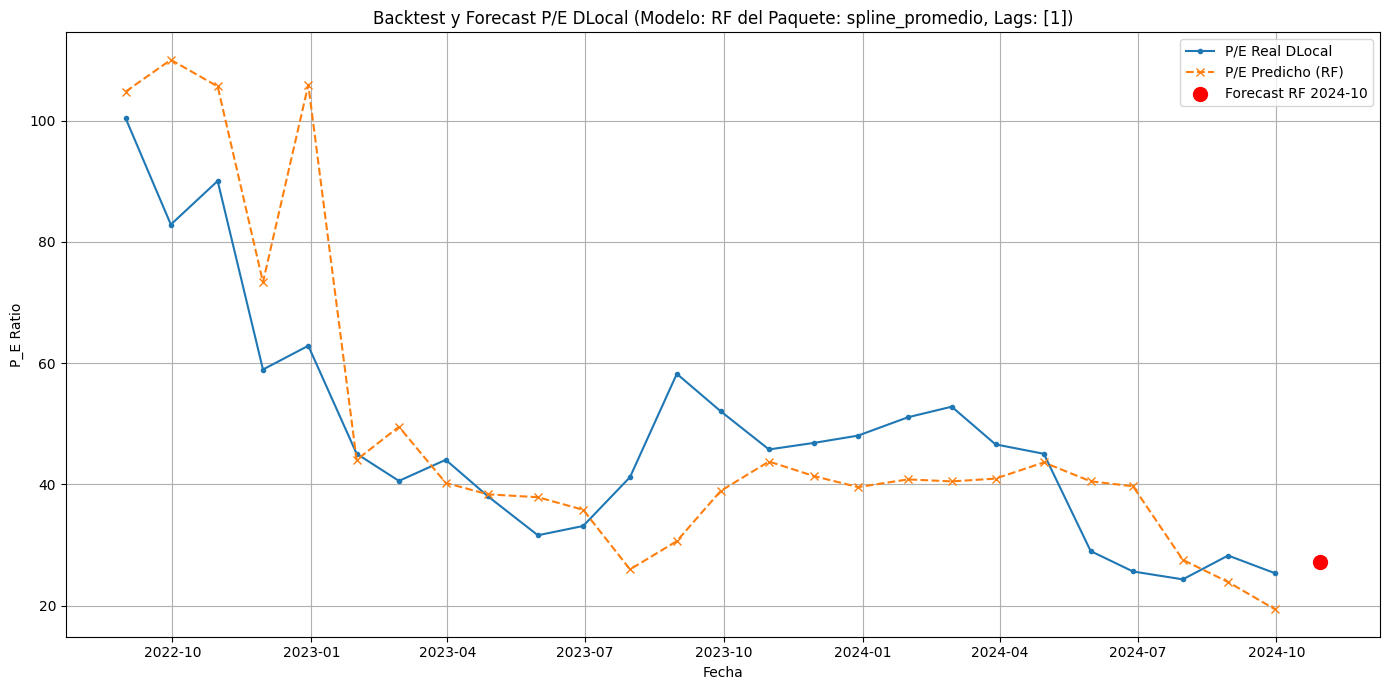


--- Procesando Modelo Tipo: XGB ---
  Features esperadas por XGB (del paquete o inferidas): 15 ['Beneficio neto_sp_lag1', 'Cap de mercado_sp_lag1', 'Deuda a LP_sp_lag1', 'Efectivo y equiv_sp_lag1', 'P_B_lag1']...
  Métricas Backtest (XGB): RMSE=14.8375, MAE=11.4628, R2=0.3831


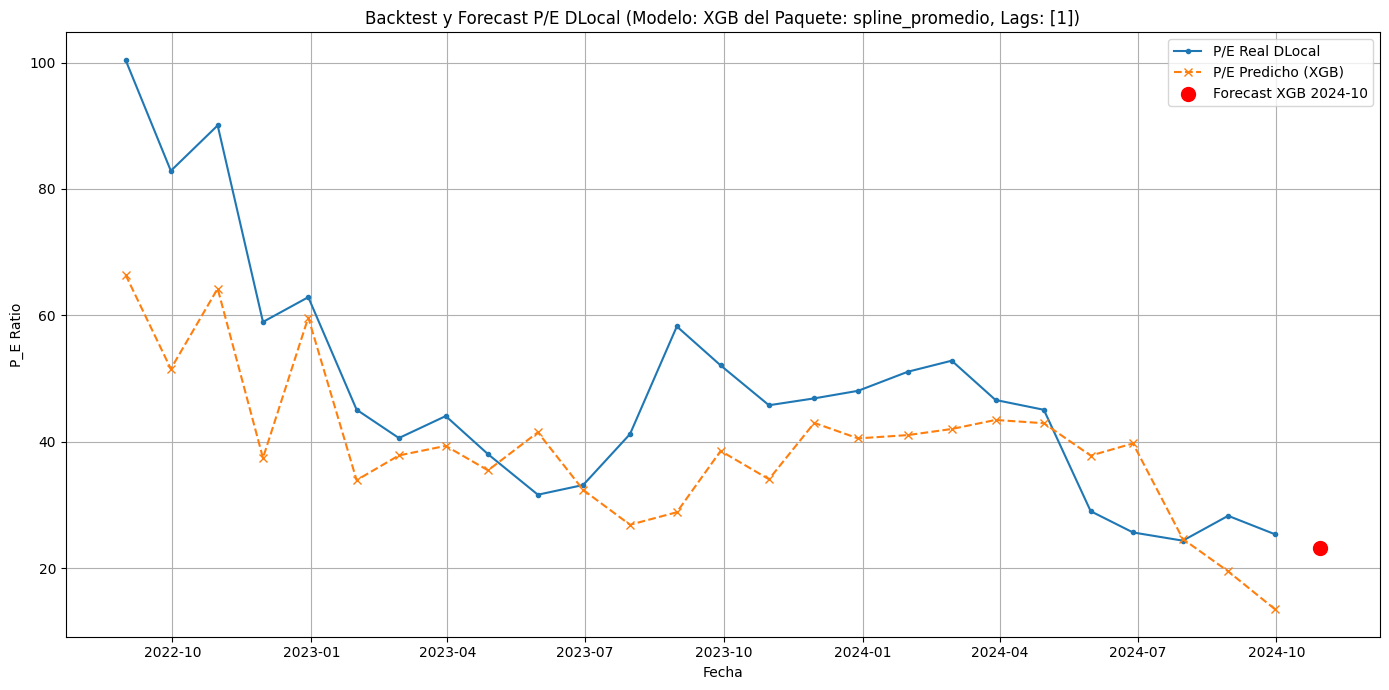


--- Procesando Modelo Tipo: LGBM ---
  Features esperadas por LGBM (del paquete o inferidas): 15 ['Beneficio neto_sp_lag1', 'Cap de mercado_sp_lag1', 'Deuda a LP_sp_lag1', 'Efectivo y equiv_sp_lag1', 'P_B_lag1']...
  Métricas Backtest (LGBM): RMSE=11.7881, MAE=8.3890, R2=0.6106


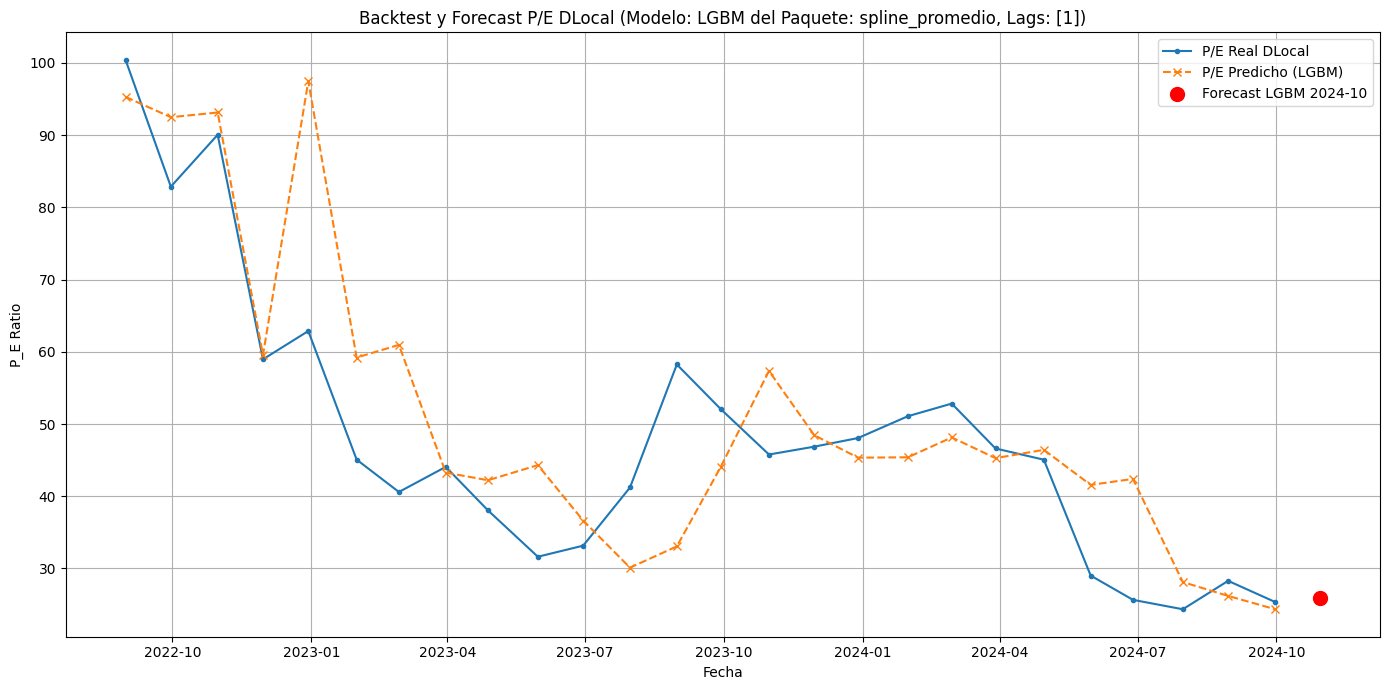


--- Procesando Modelo Tipo: CB ---
  Features esperadas por CB (del paquete o inferidas): 15 ['Beneficio neto_sp_lag1', 'Cap de mercado_sp_lag1', 'Deuda a LP_sp_lag1', 'Efectivo y equiv_sp_lag1', 'P_B_lag1']...
  Métricas Backtest (CB): RMSE=12.5849, MAE=9.4966, R2=0.5562


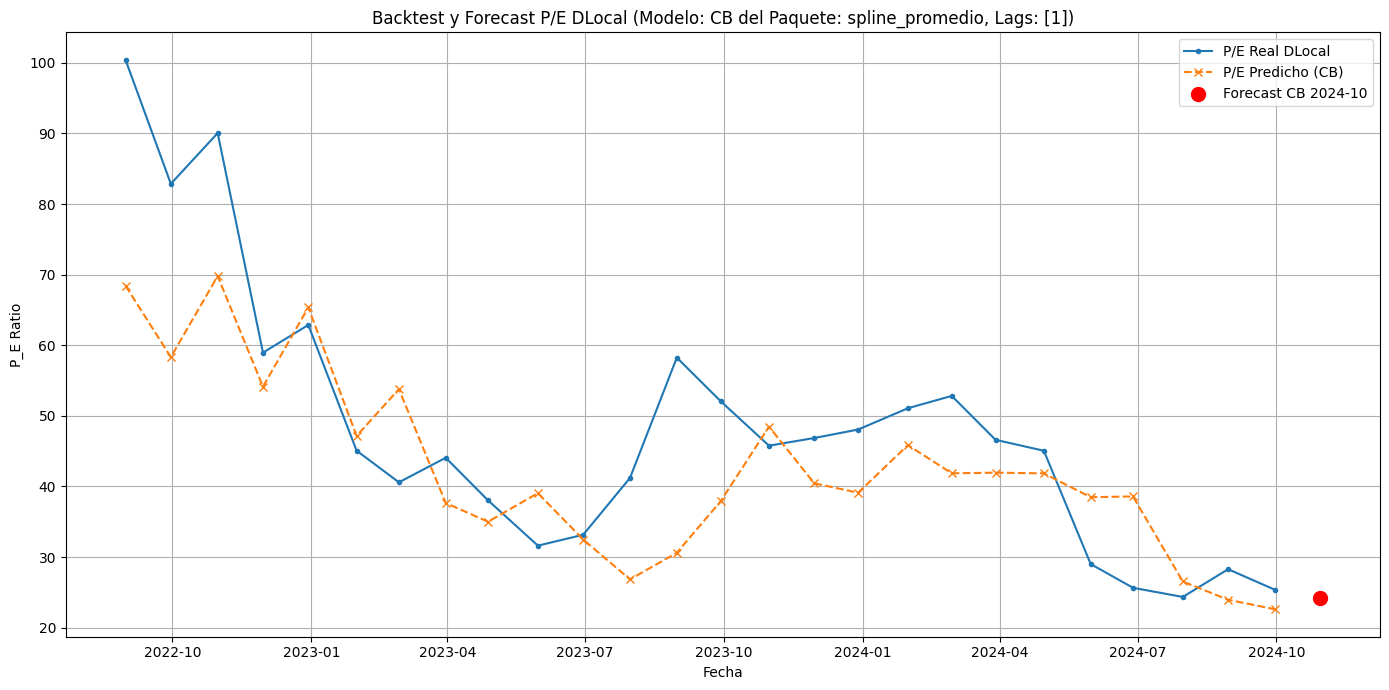


Resumen de Métricas Individuales de los Modelos en el Backtest de DLocal
Modelo_Tipo    RMSE     MAE     R2
       LGBM 11.7881  8.3890 0.6106
         CB 12.5849  9.4966 0.5562
         RF 14.0851 10.3168 0.4441
        XGB 14.8375 11.4628 0.3831

Proceso de predicción para DLocal completado.


In [40]:
# =====================================================================================
# BLOQUE DE PREDICCIÓN PARA DLOCAL (MODELOS INDIVIDUALES - GRÁFICOS Y MÉTRICAS)
# =====================================================================================

# --- 0. CONFIGURACIÓN Y CARGA DEL PAQUETE DEL MODELO ---
# ASUME: df_dlocal está cargado.
#        listas_columnas está definida (si es necesaria como fallback para columnas_base_paquete).
#        El paquete fue entrenado incluyendo P_E_lagN como feature si se desea usar aquí.

nombre_paquete_a_cargar = "paquete_mejores_por_tipo_spline_promedio__lag1_con_DropColumns.joblib"

print(f"Cargando paquete de modelos desde: {nombre_paquete_a_cargar}")
model_package = None
try:
    ruta_paquete = os.path.join(os.getcwd(), nombre_paquete_a_cargar)
    if not os.path.exists(ruta_paquete):
        raise FileNotFoundError(f"El archivo del paquete '{ruta_paquete}' no existe.")
    model_package = joblib.load(ruta_paquete)
    print("Paquete de modelos cargado exitosamente.")

    required_keys = ['metodo_features', 'lag_config_usada', 'log_transform_target', 'mejores_modelos_info_por_tipo']
    if not isinstance(model_package, dict) or not all(key in model_package for key in required_keys):
        raise ValueError("El archivo cargado no es un paquete de modelos válido o le faltan claves esenciales.")

    metodo_features_paquete = model_package['metodo_features']
    lag_config_paquete = model_package['lag_config_usada'] 
    log_transform_paquete = model_package['log_transform_target']
    columnas_base_paquete = model_package.get('columnas_base_para_lags') # Esta clave debe existir en tu paquete
    mejores_modelos_info = model_package['mejores_modelos_info_por_tipo']

    if not columnas_base_paquete: # Fallback si no está en el paquete
        print("ADVERTENCIA: 'columnas_base_para_lags' no encontrada en el paquete. Intentando usar 'listas_columnas'.")
        if 'listas_columnas' in locals() and metodo_features_paquete in listas_columnas:
            columnas_base_paquete = listas_columnas[metodo_features_paquete]
            # Si P_E_lagN se usó y 'P_E' no está en listas_columnas[metodo_features_paquete], hay que añadirlo:
            # Esta lógica asume que si P_E_lagN es una feature, 'P_E' debe estar en las bases para generar ese lag.
            # El paquete idealmente ya tendría 'P_E' en 'columnas_base_para_lags' si P_E_lagN fue usado.
            # Si el paquete es de "solo lags de P/E", columnas_base_paquete debería ser ['P_E'].
            if 'P_E' not in columnas_base_paquete and any(f.startswith("P_E_lag") for f_dict in mejores_modelos_info.values() if f_dict and 'features_usadas_por_modelo' in f_dict for f in f_dict['features_usadas_por_modelo']):
                 if 'P_E' in df_dlocal.columns:
                    print("Añadiendo 'P_E' a columnas_base_paquete para generar su lag, basado en features de modelos.")
                    columnas_base_paquete.append('P_E')
                    columnas_base_paquete = sorted(list(set(columnas_base_paquete)))
        else: 
            raise ValueError("No se pudieron determinar las 'columnas_base_para_lags' ni del paquete ni de 'listas_columnas'.")
    
    print(f"  Información del Paquete: Método={metodo_features_paquete}, LagConfig={lag_config_paquete}, LogT={log_transform_paquete}")
    print(f"    Columnas Base (usadas para generar lags): {len(columnas_base_paquete)} {columnas_base_paquete[:5]}...")
    if 'P_E' in columnas_base_paquete:
        print("    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.")
    else:
        print("    ADVERTENCIA: 'P_E' NO está en columnas_base_paquete. NO se generará P_E_lagN como feature para DLocal, a menos que lag_config_paquete lo fuerce.")

except FileNotFoundError: raise FileNotFoundError(f"ERROR FATAL: No se encontró el archivo del paquete '{nombre_paquete_a_cargar}'.")
except Exception as e_load_pack: raise RuntimeError(f"Error fatal al cargar o procesar el paquete: {e_load_pack}")

if 'df_dlocal' not in locals() or not isinstance(df_dlocal, pd.DataFrame) or df_dlocal.empty:
     raise NameError("'df_dlocal' no definido o vacío.")

# Determinar qué lags generar para DLocal basado en lag_config_paquete
lags_a_generar_dlocal = []
temp_lag_str_cfg = str(lag_config_paquete).lower()
temp_lag_str_cfg = temp_lag_str_cfg.replace('pe_lags_', '').replace('_solo_pred', '').replace('lags_', '').replace('lag', '')
found_numbers_cfg = re.findall(r'\d+', temp_lag_str_cfg)
if found_numbers_cfg:
    lags_a_generar_dlocal = sorted(list(set(int(num) for num in found_numbers_cfg)))
if not lags_a_generar_dlocal: # Fallback
    for i in range(1, 7): 
        if f"lag{i}" in str(lag_config_paquete).lower() or f"_{i}" in str(lag_config_paquete): 
            lags_a_generar_dlocal.append(i)
    lags_a_generar_dlocal = sorted(list(set(lags_a_generar_dlocal)))
if not lags_a_generar_dlocal:
    raise ValueError(f"No se pudo determinar qué lags numéricos generar a partir de lag_config_paquete: '{lag_config_paquete}'")
print(f"Se generarán lags {lags_a_generar_dlocal} para DLocal.")


# --- 1. PREPARAR df_dlocal ---
print("\n" + "="*80 + f"\nPreparando datos de DLocal (Método: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})" + "\n" + "="*80)
df_dlocal_procesado_base = df_dlocal.copy()

# 1.1 Conversión Numérica
# Usar 'columnas_base_paquete' que ahora debería incluir 'P_E' si P_E_lagN es una feature.
cols_convertir_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
for col in cols_convertir_dlocal:
    if not pd.api.types.is_numeric_dtype(df_dlocal_procesado_base[col]):
        df_dlocal_procesado_base[col] = pd.to_numeric(df_dlocal_procesado_base[col], errors='coerce')

# 1.2 Imputación Pre-Lag
cols_imputar_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
if cols_imputar_dlocal:
    df_dlocal_procesado_base.sort_values(['Empresa', 'Fecha'], inplace=True)
    if df_dlocal_procesado_base['Empresa'].nunique() > 1:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base.groupby('Empresa')[cols_imputar_dlocal].ffill()
    else:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].ffill()
    df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].fillna(0)

# 1.3 Generar Lags
# 'features_para_generar_lags_dlocal' se basa en 'columnas_base_paquete'
features_para_generar_lags_dlocal = [c for c in columnas_base_paquete if c in df_dlocal_procesado_base.columns]
# Asegurar que P_E esté si se espera P_E_lagN y no está ya en features_para_generar_lags_dlocal
# (Esta lógica es un poco redundante si columnas_base_paquete ya es correcta)
if any(f"P_E_lag{lg}" in model_info_actual.get('features_usadas_por_modelo',[]) for lg in lags_a_generar_dlocal for model_info_actual in mejores_modelos_info.values() if model_info_actual) \
   and 'P_E' not in features_para_generar_lags_dlocal and 'P_E' in df_dlocal_procesado_base.columns:
    print("  Asegurando que 'P_E' se incluya para generar sus lags para DLocal.")
    features_para_generar_lags_dlocal.append('P_E')
    features_para_generar_lags_dlocal = sorted(list(set(features_para_generar_lags_dlocal)))


cols_necesarias_para_base_df = ['Empresa', 'Fecha']
if 'P_E' in df_dlocal_procesado_base.columns: cols_necesarias_para_base_df.append('P_E')
for f_lag in features_para_generar_lags_dlocal:
    if f_lag not in cols_necesarias_para_base_df: cols_necesarias_para_base_df.append(f_lag)

df_dlocal_con_todos_lags = df_dlocal_procesado_base[cols_necesarias_para_base_df].copy()
all_generated_lag_cols_dlocal = []

print(f"Generando lags para DLocal para las features: {features_para_generar_lags_dlocal}")
for lag_val in lags_a_generar_dlocal:
    for col_base_para_lag in features_para_generar_lags_dlocal:
        lag_col_name = f"{col_base_para_lag}_lag{lag_val}"
        df_dlocal_con_todos_lags[lag_col_name] = df_dlocal_con_todos_lags.groupby('Empresa')[col_base_para_lag].shift(lag_val)
        all_generated_lag_cols_dlocal.append(lag_col_name)
all_generated_lag_cols_dlocal = sorted(list(set(all_generated_lag_cols_dlocal)))
print(f"Se generaron {len(all_generated_lag_cols_dlocal)} columnas de lag para DLocal: {all_generated_lag_cols_dlocal[:5]}...")
# Confirmación de P_E_lagN
pe_lags_actually_generated = [col for col in all_generated_lag_cols_dlocal if col.startswith("P_E_lag")]
if pe_lags_actually_generated:
    print(f"    ¡Confirmado! Lags de P/E generados: {pe_lags_actually_generated}")
else:
    print("    ADVERTENCIA: NO se generaron lags de P/E para DLocal. Verifica 'columnas_base_paquete' y la lógica de generación de lags.")

# 1.4 Aplicar dropna
df_dlocal_final_features_con_ids = df_dlocal_con_todos_lags.dropna(subset=all_generated_lag_cols_dlocal).copy()
if df_dlocal_final_features_con_ids.empty: raise ValueError("DLocal vacío post lags y dropna.")
print(f"DataFrame DLocal procesado y listo (con IDs y lags): {df_dlocal_final_features_con_ids.shape}")

# --- 2. ITERAR, PREDECIR, EVALUAR INDIVIDUALMENTE Y GRAFICAR ---
print("\n" + "="*80 + "\nIterando sobre modelos por tipo para predicción, evaluación y graficación individual en DLocal" + "\n" + "="*80)
lista_metricas_individuales_dlocal = []

for tipo_modelo_actual, model_info_actual in mejores_modelos_info.items():
    print(f"\n--- Procesando Modelo Tipo: {tipo_modelo_actual} ---")

    if model_info_actual is None or 'pipeline_object' not in model_info_actual or model_info_actual['pipeline_object'] is None:
        print(f"  No hay un pipeline válido para '{tipo_modelo_actual}'. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    pipeline_cargado_actual = model_info_actual['pipeline_object']
    estimador_real_actual = pipeline_cargado_actual
    if hasattr(pipeline_cargado_actual, 'steps'): estimador_real_actual = pipeline_cargado_actual.steps[-1][1]
    
    # Obtener las features que este modelo específico espera (guardadas en el paquete)
    features_esperadas_por_modelo_actual = model_info_actual.get('features_usadas_por_modelo', [])
    
    if not features_esperadas_por_modelo_actual: # Fallback si no se guardaron en el paquete
        print(f"  ADVERTENCIA para {tipo_modelo_actual}: 'features_usadas_por_modelo' no encontrada en el paquete. Intentando inferir...")
        if hasattr(estimador_real_actual, 'feature_names_in_'):
            features_esperadas_por_modelo_actual = list(estimador_real_actual.feature_names_in_)
        elif hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == len(all_generated_lag_cols_dlocal):
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        elif tipo_modelo_actual == 'CB' and hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == 0 and len(all_generated_lag_cols_dlocal) > 0:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        else:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal # Último recurso
            print(f"    Usando todos los {len(all_generated_lag_cols_dlocal)} lags generados como fallback final.")

    if not features_esperadas_por_modelo_actual:
        print(f"  Error: Lista final de features esperadas vacía para {tipo_modelo_actual}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    print(f"  Features esperadas por {tipo_modelo_actual} (del paquete o inferidas): {len(features_esperadas_por_modelo_actual)} {features_esperadas_por_modelo_actual[:5]}...")

    missing_features_in_dlocal = [f for f in features_esperadas_por_modelo_actual if f not in df_dlocal_final_features_con_ids.columns]
    if missing_features_in_dlocal:
        print(f"  ERROR para {tipo_modelo_actual}: Faltan features en DLocal que el modelo espera: {missing_features_in_dlocal}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    X_dlocal_input_this_model = df_dlocal_final_features_con_ids[features_esperadas_por_modelo_actual].copy()
    df_dlocal_eval_data_this_model = df_dlocal_final_features_con_ids[['Fecha', 'P_E']].loc[X_dlocal_input_this_model.index].copy()
    
    if X_dlocal_input_this_model.empty:
        print(f"  Input para {tipo_modelo_actual} vacío. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
    
    n_rows_pred_this_model = len(X_dlocal_input_this_model); fechas_p_individual, preds_p_individual, reales_p_individual = [], [], []
    if n_rows_pred_this_model > 0:
        if n_rows_pred_this_model > 1: # Backtest
            for i in range(1, n_rows_pred_this_model):
                X_pred_row_loop = X_dlocal_input_this_model.iloc[[i-1]]
                try:
                    pred_raw_loop = pipeline_cargado_actual.predict(X_pred_row_loop)[0]
                    pred_orig_loop = np.expm1(pred_raw_loop) if log_transform_paquete else pred_raw_loop
                    if log_transform_paquete and not np.isfinite(pred_orig_loop): pred_orig_loop = np.nan
                except Exception as e_pred_loop:
                    pred_orig_loop = np.nan
                    print(f"    Error en backtest para {tipo_modelo_actual} (Fecha target: {df_dlocal_eval_data_this_model.iloc[i]['Fecha']}): {e_pred_loop}")
                preds_p_individual.append(pred_orig_loop)
                fechas_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['Fecha'])
                reales_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['P_E'])
        
        X_forecast_row_loop = X_dlocal_input_this_model.iloc[[-1]]; pronostico_final_individual = np.nan
        try:
            pred_raw_forecast_loop = pipeline_cargado_actual.predict(X_forecast_row_loop)[0]
            pronostico_final_individual = np.expm1(pred_raw_forecast_loop) if log_transform_paquete else pred_raw_forecast_loop
            if log_transform_paquete and not np.isfinite(pronostico_final_individual): pronostico_final_individual = np.nan
        except Exception as e_forecast_ind:
             print(f"    Error durante el forecast para {tipo_modelo_actual}: {e_forecast_ind}")
        
        proxima_fecha_individual = "Periodo Siguiente"
        if not df_dlocal_eval_data_this_model.empty and 'Fecha' in df_dlocal_eval_data_this_model.columns and not df_dlocal_eval_data_this_model['Fecha'].empty:
            try: proxima_fecha_individual = df_dlocal_eval_data_this_model['Fecha'].iloc[-1] + pd.DateOffset(months=1)
            except: pass
            
        df_backtest_individual = pd.DataFrame({'Fecha': fechas_p_individual, 'P_E_Predicho': preds_p_individual, 'P_E_Real': reales_p_individual})
        
        metricas_individual_actual = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
        if not df_backtest_individual.empty:
            metricas_individual_actual = evaluate_model(df_backtest_individual['P_E_Real'], df_backtest_individual['P_E_Predicho'])
            print(f"  Métricas Backtest ({tipo_modelo_actual}): RMSE={metricas_individual_actual['RMSE']:.4f}, MAE={metricas_individual_actual['MAE']:.4f}, R2={metricas_individual_actual['R2']:.4f}")
        
        metricas_a_guardar = metricas_individual_actual.copy()
        metricas_a_guardar['Modelo_Tipo'] = tipo_modelo_actual
        lista_metricas_individuales_dlocal.append(metricas_a_guardar)

        if not df_backtest_individual.empty:
            plt.figure(figsize=(14, 7))
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Real'], marker='.', linestyle='-', label='P/E Real DLocal')
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Predicho'], marker='x', linestyle='--', label=f'P/E Predicho ({tipo_modelo_actual})')
            if isinstance(proxima_fecha_individual, pd.Timestamp) and pd.notna(pronostico_final_individual):
                 plt.scatter([proxima_fecha_individual], [pronostico_final_individual], color='red', label=f'Forecast {tipo_modelo_actual} {proxima_fecha_individual.strftime("%Y-%m")}', zorder=5, s=100)
            plt.title(f'Backtest y Forecast P/E DLocal (Modelo: {tipo_modelo_actual} del Paquete: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})')
            plt.xlabel('Fecha'); plt.ylabel('P_E Ratio'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
    else:
        print(f"  No hay datos suficientes en DLocal procesado para hacer predicciones con {tipo_modelo_actual}.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})

# --- 3. IMPRIMIR TABLA DE MÉTRICAS INDIVIDUALES (AL FINAL) ---
if lista_metricas_individuales_dlocal:
    df_metricas_final_dlocal = pd.DataFrame(lista_metricas_individuales_dlocal)
    print("\n" + "="*80 + "\nResumen de Métricas Individuales de los Modelos en el Backtest de DLocal" + "\n" + "="*80)
    df_metricas_final_dlocal_sorted = df_metricas_final_dlocal.sort_values(by='RMSE', ascending=True)
    columnas_ordenadas_metricas = ['Modelo_Tipo', 'RMSE', 'MAE', 'R2']
    columnas_existentes_para_print = [col for col in columnas_ordenadas_metricas if col in df_metricas_final_dlocal_sorted.columns]
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.4f}'.format):
        print(df_metricas_final_dlocal_sorted[columnas_existentes_para_print].to_string(index=False))
else:
    print("\nNo se generaron métricas para DLocal o la lista está vacía.")

print("\n" + "="*80 + "\nProceso de predicción para DLocal completado." + "\n" + "="*80)

#### Con transformación logarítmica

In [41]:

# ----- flag para versión con / sin log -------------
use_log = True          # cambia a True si quieres log(1+P_E)

# -------------- loop principal ---------------------
results = []

for metodo in dfs_shifted_train.keys():
    df_tr = dfs_shifted_train[metodo]
    df_te = dfs_shifted_test[metodo]

    if df_tr.empty or df_te.empty:
        print(f"[{metodo}] sin datos tras lags – se omite.")
        continue

    X_tr, y_tr = df_tr.drop(columns=['P_E']), df_tr['P_E']
    X_te, y_te = df_te.drop(columns=['P_E']), df_te['P_E']

    if use_log:
        y_tr = np.log1p(y_tr.clip(lower=0))

    id_cols = ['Empresa','Fecha','time_step']   # ‘time_step’ por si lo tienes
    drop_ids = DropColumns(columns=[c for c in id_cols if c in X_tr.columns])

    for sc_name, cfg in scenarios.items():
        t0 = time.time()

        pipe = Pipeline([('drop', drop_ids),
                         ('model', cfg['model'])])

        # --- CV interno (si hp=True) solo con TRAIN ---
        if cfg['hp']:
            cv = (GroupKFold(n_splits=3)
                  if cfg['vt'] and 'Empresa' in X_tr.columns
                  else KFold(n_splits=3, shuffle=True, random_state=42))

            groups = X_tr['Empresa'] if cfg['vt'] and 'Empresa' in X_tr.columns else None

            gs = GridSearchCV(pipe, cfg['grid'], scoring=rmse_scorer,
                              cv=cv, refit=True, n_jobs=-1)
            gs.fit(X_tr, y_tr, groups=groups)
            model_fitted = gs.best_estimator_
            best_params  = gs.best_params_
        else:
            pipe.fit(X_tr, y_tr)
            model_fitted = pipe
            best_params  = None

        # --------- evaluación en TEST -------------
        y_hat = model_fitted.predict(X_te)
        if use_log:
            y_hat = np.expm1(y_hat)

        metrics = eval_metrics(y_te, y_hat)
        metrics.update(dict(Metodo=metodo,
                            Escenario=sc_name,
                            Modelo=sc_name.split('_')[0],
                            HP=cfg['hp'],
                            VT=cfg['vt'],
                            LogTarget=use_log,
                            Tiempo=f"{time.time()-t0:.1f}s",
                            BestParams=best_params))
        results.append(metrics)

        print(f"[{metodo} | {sc_name}]  RMSE={metrics['RMSE']:.3f}  R²={metrics['R2']:.3f}")

# -------------- tabla final -----------------------
df_results = (pd.DataFrame(results)
              .sort_values(['Metodo','RMSE'])
              .reset_index(drop=True))

with pd.option_context('display.max_rows', 200,
                       'display.float_format', '{:.4f}'.format):
    print("\n================  RESUMEN  ================")
    print(df_results[['Metodo','Escenario','RMSE','MAE','R2']].to_string(index=False))

# -------------- (opcional) guarda el mejor de cada método -----
for metodo in df_results['Metodo'].unique():
    row = df_results[df_results['Metodo']==metodo].iloc[0]
    fname = f"best_{metodo}_{row.Escenario}_{'log' if use_log else 'linear'}.joblib"
    # row['BestParams'] contiene el dict; para guardar el pipeline usa model_fitted
    # (podrías almacenarlo en un dict aparte si lo necesitas)


[lineal_mediana | RF_Simple]  RMSE=17.574  R²=0.645
[lineal_mediana | RF_HP]  RMSE=17.457  R²=0.650
[lineal_mediana | XGB_Simple]  RMSE=16.870  R²=0.673
[lineal_mediana | XGB_HP]  RMSE=16.139  R²=0.701
[lineal_mediana | LGBM_Simple]  RMSE=17.398  R²=0.652
[lineal_mediana | LGBM_HP]  RMSE=17.483  R²=0.649
[lineal_mediana | CB_Simple]  RMSE=16.718  R²=0.679
[lineal_mediana | CB_HP]  RMSE=16.006  R²=0.706
[spline_mediana | RF_Simple]  RMSE=17.160  R²=0.661
[spline_mediana | RF_HP]  RMSE=16.826  R²=0.675
[spline_mediana | XGB_Simple]  RMSE=16.814  R²=0.675
[spline_mediana | XGB_HP]  RMSE=16.068  R²=0.703
[spline_mediana | LGBM_Simple]  RMSE=17.503  R²=0.648
[spline_mediana | LGBM_HP]  RMSE=17.343  R²=0.654
[spline_mediana | CB_Simple]  RMSE=16.954  R²=0.670
[spline_mediana | CB_HP]  RMSE=16.018  R²=0.705
[lineal_promedio | RF_Simple]  RMSE=17.547  R²=0.646
[lineal_promedio | RF_HP]  RMSE=17.444  R²=0.650
[lineal_promedio | XGB_Simple]  RMSE=16.450  R²=0.689
[lineal_promedio | XGB_HP]  RMSE

In [43]:
df_results.sort_values(by=["R2"], ascending=False)

,RMSE,MAE,R2,Metodo,Escenario,Modelo,HP,VT,LogTarget,Tiempo,BestParams
8,15.551089,2.560377,0.721996,lineal_promedio,XGB_HP,XGB,True,False,True,3.7s,"{'model__learning_rate': 0.1, 'model__max_dept..."
0,16.005783,2.639761,0.705501,lineal_mediana,CB_HP,CB,True,False,True,10.1s,"{'model__depth': 5, 'model__iterations': 200, ..."
16,16.018269,2.685743,0.705042,spline_mediana,CB_HP,CB,True,False,True,11.7s,"{'model__depth': 5, 'model__iterations': 200, ..."
9,16.042182,2.671927,0.704160,lineal_promedio,CB_HP,CB,True,False,True,12.0s,"{'model__depth': 5, 'model__iterations': 200, ..."
17,16.067582,2.648483,0.703223,spline_mediana,XGB_HP,XGB,True,False,True,3.4s,"{'model__learning_rate': 0.1, 'model__max_dept..."
1,16.139077,2.609782,0.700576,lineal_mediana,XGB_HP,XGB,True,False,True,2.6s,"{'model__learning_rate': 0.1, 'model__max_dept..."
10,16.450238,2.667801,0.688919,lineal_promedio,XGB_Simple,XGB,False,False,True,0.5s,None
24,16.528887,2.637623,0.685937,spline_promedio,CB_Simple,CB,False,False,True,7.4s,None
25,16.556711,2.654783,0.684879,spline_promedio,XGB_HP,XGB,True,False,True,3.4s,"{'model__learning_rate': 0.1, 'model__max_dept..."
26,16.679057,2.795405,0.680204,spline_promedio,XGB_Simple,XGB,False,False,True,0.5s,None


Cargando paquete de modelos desde: paquete_mejores_por_tipo_lineal_promedio__lag1_con_DropColumns.joblib
Paquete de modelos cargado exitosamente.
  Información del Paquete: Método=lineal_promedio, LagConfig=_lag1_con_DropColumns, LogT=True
    Columnas Base (usadas para generar lags): 15 ['Beneficio neto_l', 'Cap de mercado_l', 'Deuda a LP_l', 'Efectivo y equiv_l', 'P_B']...
    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.
Se generarán lags [1] para DLocal.

Preparando datos de DLocal (Método: lineal_promedio, Lags: [1])
Generando lags para DLocal para las features: ['Beneficio neto_l', 'Cap de mercado_l', 'Deuda a LP_l', 'Efectivo y equiv_l', 'P_B', 'P_E', 'P_S', 'P_Share', 'ROA_l', 'ROCE_l', 'ROI_l', 'Total Activos_l', 'dif_CPI_promedio', 'dif_FFR_promedio', 'dif_NFP_promedio']
Se generaron 15 columnas de lag para DLocal: ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
    ¡Confirm

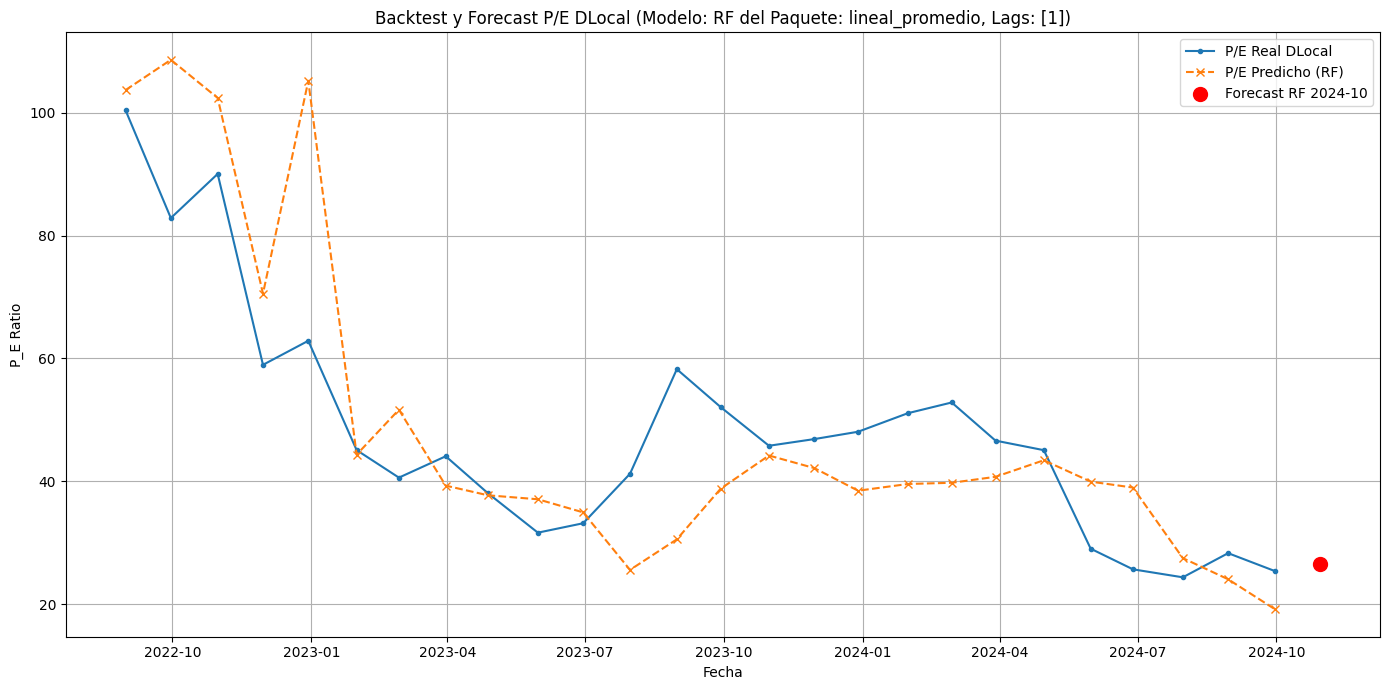


--- Procesando Modelo Tipo: XGB ---
  Features esperadas por XGB (del paquete o inferidas): 15 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
  Métricas Backtest (XGB): RMSE=14.0424, MAE=11.7564, R2=0.4474


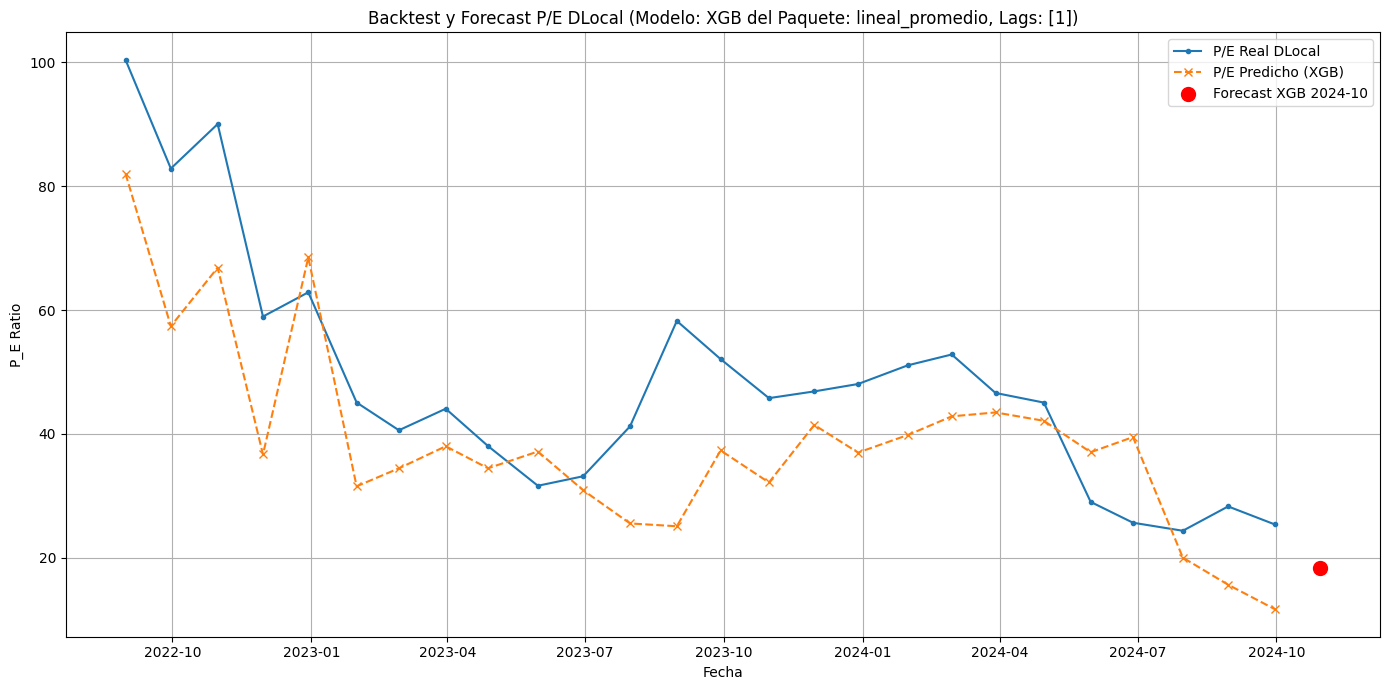


--- Procesando Modelo Tipo: LGBM ---
  Features esperadas por LGBM (del paquete o inferidas): 15 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
  Métricas Backtest (LGBM): RMSE=10.7603, MAE=7.9953, R2=0.6755


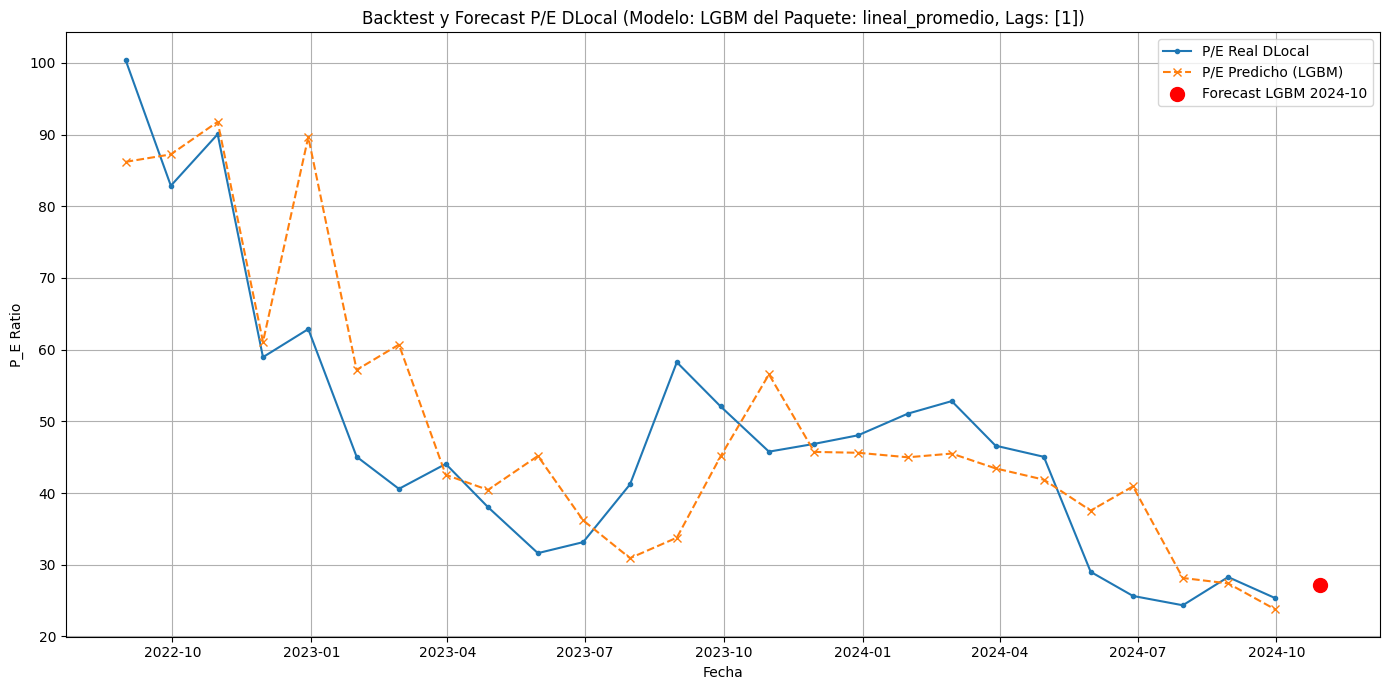


--- Procesando Modelo Tipo: CB ---
  Features esperadas por CB (del paquete o inferidas): 15 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a LP_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1']...
  Métricas Backtest (CB): RMSE=11.1912, MAE=8.5663, R2=0.6490


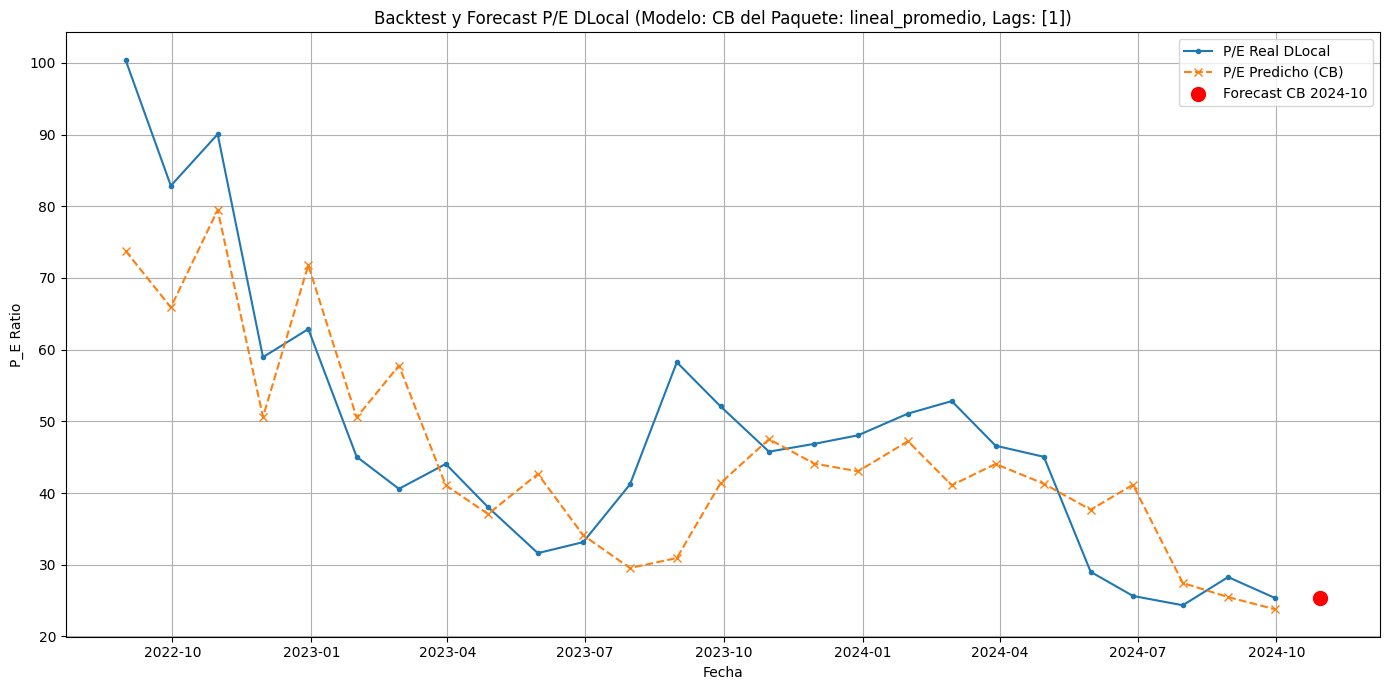


Resumen de Métricas Individuales de los Modelos en el Backtest de DLocal
Modelo_Tipo    RMSE     MAE     R2
       LGBM 10.7603  7.9953 0.6755
         CB 11.1912  8.5663 0.6490
         RF 13.7913 10.0775 0.4670
        XGB 14.0424 11.7564 0.4474

Proceso de predicción para DLocal completado.


In [45]:
# =====================================================================================
# BLOQUE DE PREDICCIÓN PARA DLOCAL (MODELOS INDIVIDUALES - GRÁFICOS Y MÉTRICAS)
# =====================================================================================

# --- 0. CONFIGURACIÓN Y CARGA DEL PAQUETE DEL MODELO ---
# ASUME: df_dlocal está cargado.
#        listas_columnas está definida (si es necesaria como fallback para columnas_base_paquete).
#        El paquete fue entrenado incluyendo P_E_lagN como feature si se desea usar aquí.

nombre_paquete_a_cargar = "paquete_mejores_por_tipo_lineal_promedio__lag1_con_DropColumns.joblib"

print(f"Cargando paquete de modelos desde: {nombre_paquete_a_cargar}")
model_package = None
try:
    ruta_paquete = os.path.join(os.getcwd(), nombre_paquete_a_cargar)
    if not os.path.exists(ruta_paquete):
        raise FileNotFoundError(f"El archivo del paquete '{ruta_paquete}' no existe.")
    model_package = joblib.load(ruta_paquete)
    print("Paquete de modelos cargado exitosamente.")

    required_keys = ['metodo_features', 'lag_config_usada', 'log_transform_target', 'mejores_modelos_info_por_tipo']
    if not isinstance(model_package, dict) or not all(key in model_package for key in required_keys):
        raise ValueError("El archivo cargado no es un paquete de modelos válido o le faltan claves esenciales.")

    metodo_features_paquete = model_package['metodo_features']
    lag_config_paquete = model_package['lag_config_usada'] 
    log_transform_paquete = model_package['log_transform_target']
    columnas_base_paquete = model_package.get('columnas_base_para_lags') # Esta clave debe existir en tu paquete
    mejores_modelos_info = model_package['mejores_modelos_info_por_tipo']

    if not columnas_base_paquete: # Fallback si no está en el paquete
        print("ADVERTENCIA: 'columnas_base_para_lags' no encontrada en el paquete. Intentando usar 'listas_columnas'.")
        if 'listas_columnas' in locals() and metodo_features_paquete in listas_columnas:
            columnas_base_paquete = listas_columnas[metodo_features_paquete]
            # Si P_E_lagN se usó y 'P_E' no está en listas_columnas[metodo_features_paquete], hay que añadirlo:
            # Esta lógica asume que si P_E_lagN es una feature, 'P_E' debe estar en las bases para generar ese lag.
            # El paquete idealmente ya tendría 'P_E' en 'columnas_base_para_lags' si P_E_lagN fue usado.
            # Si el paquete es de "solo lags de P/E", columnas_base_paquete debería ser ['P_E'].
            if 'P_E' not in columnas_base_paquete and any(f.startswith("P_E_lag") for f_dict in mejores_modelos_info.values() if f_dict and 'features_usadas_por_modelo' in f_dict for f in f_dict['features_usadas_por_modelo']):
                 if 'P_E' in df_dlocal.columns:
                    print("Añadiendo 'P_E' a columnas_base_paquete para generar su lag, basado en features de modelos.")
                    columnas_base_paquete.append('P_E')
                    columnas_base_paquete = sorted(list(set(columnas_base_paquete)))
        else: 
            raise ValueError("No se pudieron determinar las 'columnas_base_para_lags' ni del paquete ni de 'listas_columnas'.")
    
    print(f"  Información del Paquete: Método={metodo_features_paquete}, LagConfig={lag_config_paquete}, LogT={log_transform_paquete}")
    print(f"    Columnas Base (usadas para generar lags): {len(columnas_base_paquete)} {columnas_base_paquete[:5]}...")
    if 'P_E' in columnas_base_paquete:
        print("    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.")
    else:
        print("    ADVERTENCIA: 'P_E' NO está en columnas_base_paquete. NO se generará P_E_lagN como feature para DLocal, a menos que lag_config_paquete lo fuerce.")

except FileNotFoundError: raise FileNotFoundError(f"ERROR FATAL: No se encontró el archivo del paquete '{nombre_paquete_a_cargar}'.")
except Exception as e_load_pack: raise RuntimeError(f"Error fatal al cargar o procesar el paquete: {e_load_pack}")

if 'df_dlocal' not in locals() or not isinstance(df_dlocal, pd.DataFrame) or df_dlocal.empty:
     raise NameError("'df_dlocal' no definido o vacío.")

# Determinar qué lags generar para DLocal basado en lag_config_paquete
lags_a_generar_dlocal = []
temp_lag_str_cfg = str(lag_config_paquete).lower()
temp_lag_str_cfg = temp_lag_str_cfg.replace('pe_lags_', '').replace('_solo_pred', '').replace('lags_', '').replace('lag', '')
found_numbers_cfg = re.findall(r'\d+', temp_lag_str_cfg)
if found_numbers_cfg:
    lags_a_generar_dlocal = sorted(list(set(int(num) for num in found_numbers_cfg)))
if not lags_a_generar_dlocal: # Fallback
    for i in range(1, 7): 
        if f"lag{i}" in str(lag_config_paquete).lower() or f"_{i}" in str(lag_config_paquete): 
            lags_a_generar_dlocal.append(i)
    lags_a_generar_dlocal = sorted(list(set(lags_a_generar_dlocal)))
if not lags_a_generar_dlocal:
    raise ValueError(f"No se pudo determinar qué lags numéricos generar a partir de lag_config_paquete: '{lag_config_paquete}'")
print(f"Se generarán lags {lags_a_generar_dlocal} para DLocal.")


# --- 1. PREPARAR df_dlocal ---
print("\n" + "="*80 + f"\nPreparando datos de DLocal (Método: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})" + "\n" + "="*80)
df_dlocal_procesado_base = df_dlocal.copy()

# 1.1 Conversión Numérica
# Usar 'columnas_base_paquete' que ahora debería incluir 'P_E' si P_E_lagN es una feature.
cols_convertir_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
for col in cols_convertir_dlocal:
    if not pd.api.types.is_numeric_dtype(df_dlocal_procesado_base[col]):
        df_dlocal_procesado_base[col] = pd.to_numeric(df_dlocal_procesado_base[col], errors='coerce')

# 1.2 Imputación Pre-Lag
cols_imputar_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
if cols_imputar_dlocal:
    df_dlocal_procesado_base.sort_values(['Empresa', 'Fecha'], inplace=True)
    if df_dlocal_procesado_base['Empresa'].nunique() > 1:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base.groupby('Empresa')[cols_imputar_dlocal].ffill()
    else:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].ffill()
    df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].fillna(0)

# 1.3 Generar Lags
# 'features_para_generar_lags_dlocal' se basa en 'columnas_base_paquete'
features_para_generar_lags_dlocal = [c for c in columnas_base_paquete if c in df_dlocal_procesado_base.columns]
# Asegurar que P_E esté si se espera P_E_lagN y no está ya en features_para_generar_lags_dlocal
# (Esta lógica es un poco redundante si columnas_base_paquete ya es correcta)
if any(f"P_E_lag{lg}" in model_info_actual.get('features_usadas_por_modelo',[]) for lg in lags_a_generar_dlocal for model_info_actual in mejores_modelos_info.values() if model_info_actual) \
   and 'P_E' not in features_para_generar_lags_dlocal and 'P_E' in df_dlocal_procesado_base.columns:
    print("  Asegurando que 'P_E' se incluya para generar sus lags para DLocal.")
    features_para_generar_lags_dlocal.append('P_E')
    features_para_generar_lags_dlocal = sorted(list(set(features_para_generar_lags_dlocal)))


cols_necesarias_para_base_df = ['Empresa', 'Fecha']
if 'P_E' in df_dlocal_procesado_base.columns: cols_necesarias_para_base_df.append('P_E')
for f_lag in features_para_generar_lags_dlocal:
    if f_lag not in cols_necesarias_para_base_df: cols_necesarias_para_base_df.append(f_lag)

df_dlocal_con_todos_lags = df_dlocal_procesado_base[cols_necesarias_para_base_df].copy()
all_generated_lag_cols_dlocal = []

print(f"Generando lags para DLocal para las features: {features_para_generar_lags_dlocal}")
for lag_val in lags_a_generar_dlocal:
    for col_base_para_lag in features_para_generar_lags_dlocal:
        lag_col_name = f"{col_base_para_lag}_lag{lag_val}"
        df_dlocal_con_todos_lags[lag_col_name] = df_dlocal_con_todos_lags.groupby('Empresa')[col_base_para_lag].shift(lag_val)
        all_generated_lag_cols_dlocal.append(lag_col_name)
all_generated_lag_cols_dlocal = sorted(list(set(all_generated_lag_cols_dlocal)))
print(f"Se generaron {len(all_generated_lag_cols_dlocal)} columnas de lag para DLocal: {all_generated_lag_cols_dlocal[:5]}...")
# Confirmación de P_E_lagN
pe_lags_actually_generated = [col for col in all_generated_lag_cols_dlocal if col.startswith("P_E_lag")]
if pe_lags_actually_generated:
    print(f"    ¡Confirmado! Lags de P/E generados: {pe_lags_actually_generated}")
else:
    print("    ADVERTENCIA: NO se generaron lags de P/E para DLocal. Verifica 'columnas_base_paquete' y la lógica de generación de lags.")

# 1.4 Aplicar dropna
df_dlocal_final_features_con_ids = df_dlocal_con_todos_lags.dropna(subset=all_generated_lag_cols_dlocal).copy()
if df_dlocal_final_features_con_ids.empty: raise ValueError("DLocal vacío post lags y dropna.")
print(f"DataFrame DLocal procesado y listo (con IDs y lags): {df_dlocal_final_features_con_ids.shape}")

# --- 2. ITERAR, PREDECIR, EVALUAR INDIVIDUALMENTE Y GRAFICAR ---
print("\n" + "="*80 + "\nIterando sobre modelos por tipo para predicción, evaluación y graficación individual en DLocal" + "\n" + "="*80)
lista_metricas_individuales_dlocal = []

for tipo_modelo_actual, model_info_actual in mejores_modelos_info.items():
    print(f"\n--- Procesando Modelo Tipo: {tipo_modelo_actual} ---")

    if model_info_actual is None or 'pipeline_object' not in model_info_actual or model_info_actual['pipeline_object'] is None:
        print(f"  No hay un pipeline válido para '{tipo_modelo_actual}'. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    pipeline_cargado_actual = model_info_actual['pipeline_object']
    estimador_real_actual = pipeline_cargado_actual
    if hasattr(pipeline_cargado_actual, 'steps'): estimador_real_actual = pipeline_cargado_actual.steps[-1][1]
    
    # Obtener las features que este modelo específico espera (guardadas en el paquete)
    features_esperadas_por_modelo_actual = model_info_actual.get('features_usadas_por_modelo', [])
    
    if not features_esperadas_por_modelo_actual: # Fallback si no se guardaron en el paquete
        print(f"  ADVERTENCIA para {tipo_modelo_actual}: 'features_usadas_por_modelo' no encontrada en el paquete. Intentando inferir...")
        if hasattr(estimador_real_actual, 'feature_names_in_'):
            features_esperadas_por_modelo_actual = list(estimador_real_actual.feature_names_in_)
        elif hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == len(all_generated_lag_cols_dlocal):
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        elif tipo_modelo_actual == 'CB' and hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == 0 and len(all_generated_lag_cols_dlocal) > 0:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        else:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal # Último recurso
            print(f"    Usando todos los {len(all_generated_lag_cols_dlocal)} lags generados como fallback final.")

    if not features_esperadas_por_modelo_actual:
        print(f"  Error: Lista final de features esperadas vacía para {tipo_modelo_actual}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    print(f"  Features esperadas por {tipo_modelo_actual} (del paquete o inferidas): {len(features_esperadas_por_modelo_actual)} {features_esperadas_por_modelo_actual[:5]}...")

    missing_features_in_dlocal = [f for f in features_esperadas_por_modelo_actual if f not in df_dlocal_final_features_con_ids.columns]
    if missing_features_in_dlocal:
        print(f"  ERROR para {tipo_modelo_actual}: Faltan features en DLocal que el modelo espera: {missing_features_in_dlocal}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    X_dlocal_input_this_model = df_dlocal_final_features_con_ids[features_esperadas_por_modelo_actual].copy()
    df_dlocal_eval_data_this_model = df_dlocal_final_features_con_ids[['Fecha', 'P_E']].loc[X_dlocal_input_this_model.index].copy()
    
    if X_dlocal_input_this_model.empty:
        print(f"  Input para {tipo_modelo_actual} vacío. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
    
    n_rows_pred_this_model = len(X_dlocal_input_this_model); fechas_p_individual, preds_p_individual, reales_p_individual = [], [], []
    if n_rows_pred_this_model > 0:
        if n_rows_pred_this_model > 1: # Backtest
            for i in range(1, n_rows_pred_this_model):
                X_pred_row_loop = X_dlocal_input_this_model.iloc[[i-1]]
                try:
                    pred_raw_loop = pipeline_cargado_actual.predict(X_pred_row_loop)[0]
                    pred_orig_loop = np.expm1(pred_raw_loop) if log_transform_paquete else pred_raw_loop
                    if log_transform_paquete and not np.isfinite(pred_orig_loop): pred_orig_loop = np.nan
                except Exception as e_pred_loop:
                    pred_orig_loop = np.nan
                    print(f"    Error en backtest para {tipo_modelo_actual} (Fecha target: {df_dlocal_eval_data_this_model.iloc[i]['Fecha']}): {e_pred_loop}")
                preds_p_individual.append(pred_orig_loop)
                fechas_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['Fecha'])
                reales_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['P_E'])
        
        X_forecast_row_loop = X_dlocal_input_this_model.iloc[[-1]]; pronostico_final_individual = np.nan
        try:
            pred_raw_forecast_loop = pipeline_cargado_actual.predict(X_forecast_row_loop)[0]
            pronostico_final_individual = np.expm1(pred_raw_forecast_loop) if log_transform_paquete else pred_raw_forecast_loop
            if log_transform_paquete and not np.isfinite(pronostico_final_individual): pronostico_final_individual = np.nan
        except Exception as e_forecast_ind:
             print(f"    Error durante el forecast para {tipo_modelo_actual}: {e_forecast_ind}")
        
        proxima_fecha_individual = "Periodo Siguiente"
        if not df_dlocal_eval_data_this_model.empty and 'Fecha' in df_dlocal_eval_data_this_model.columns and not df_dlocal_eval_data_this_model['Fecha'].empty:
            try: proxima_fecha_individual = df_dlocal_eval_data_this_model['Fecha'].iloc[-1] + pd.DateOffset(months=1)
            except: pass
            
        df_backtest_individual = pd.DataFrame({'Fecha': fechas_p_individual, 'P_E_Predicho': preds_p_individual, 'P_E_Real': reales_p_individual})
        
        metricas_individual_actual = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
        if not df_backtest_individual.empty:
            metricas_individual_actual = evaluate_model(df_backtest_individual['P_E_Real'], df_backtest_individual['P_E_Predicho'])
            print(f"  Métricas Backtest ({tipo_modelo_actual}): RMSE={metricas_individual_actual['RMSE']:.4f}, MAE={metricas_individual_actual['MAE']:.4f}, R2={metricas_individual_actual['R2']:.4f}")
        
        metricas_a_guardar = metricas_individual_actual.copy()
        metricas_a_guardar['Modelo_Tipo'] = tipo_modelo_actual
        lista_metricas_individuales_dlocal.append(metricas_a_guardar)

        if not df_backtest_individual.empty:
            plt.figure(figsize=(14, 7))
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Real'], marker='.', linestyle='-', label='P/E Real DLocal')
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Predicho'], marker='x', linestyle='--', label=f'P/E Predicho ({tipo_modelo_actual})')
            if isinstance(proxima_fecha_individual, pd.Timestamp) and pd.notna(pronostico_final_individual):
                 plt.scatter([proxima_fecha_individual], [pronostico_final_individual], color='red', label=f'Forecast {tipo_modelo_actual} {proxima_fecha_individual.strftime("%Y-%m")}', zorder=5, s=100)
            plt.title(f'Backtest y Forecast P/E DLocal (Modelo: {tipo_modelo_actual} del Paquete: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})')
            plt.xlabel('Fecha'); plt.ylabel('P_E Ratio'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
    else:
        print(f"  No hay datos suficientes en DLocal procesado para hacer predicciones con {tipo_modelo_actual}.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})

# --- 3. IMPRIMIR TABLA DE MÉTRICAS INDIVIDUALES (AL FINAL) ---
if lista_metricas_individuales_dlocal:
    df_metricas_final_dlocal = pd.DataFrame(lista_metricas_individuales_dlocal)
    print("\n" + "="*80 + "\nResumen de Métricas Individuales de los Modelos en el Backtest de DLocal" + "\n" + "="*80)
    df_metricas_final_dlocal_sorted = df_metricas_final_dlocal.sort_values(by='RMSE', ascending=True)
    columnas_ordenadas_metricas = ['Modelo_Tipo', 'RMSE', 'MAE', 'R2']
    columnas_existentes_para_print = [col for col in columnas_ordenadas_metricas if col in df_metricas_final_dlocal_sorted.columns]
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.4f}'.format):
        print(df_metricas_final_dlocal_sorted[columnas_existentes_para_print].to_string(index=False))
else:
    print("\nNo se generaron métricas para DLocal o la lista está vacía.")

print("\n" + "="*80 + "\nProceso de predicción para DLocal completado." + "\n" + "="*80)